In [1]:
import numpy as np
import random
from multiprocessing import Pool
import pandas as pd
from scipy.interpolate import interp1d
from scipy.special import gamma, erf
import scipy.stats as stats
from scipy.stats import binom

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

import sys
sys.path.insert(0, 'ExistingLimits/')
#import MichaelLimits as ML

import darklim
sys.path.insert(0, '/home/vvelan/DarkELF/')
import darkelf

import qetpy
import detprocess
import h5py
import time
import pickle
import glob

%matplotlib inline


# GaAs Detector Physics (electron-hole pair creation, and light/phonon production)

Expected mean: 1.00, Binomial Variance: 0.60, Extra Variance: 0.04
Observed mean: 1.00, Variance: 0.64


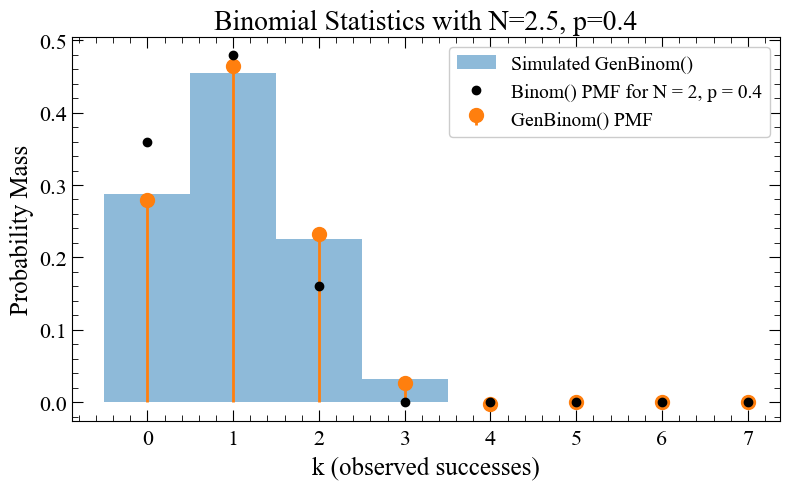

In [2]:

def generalized_binomial_pmf(k, N, p):
    """Generalized binomial PMF using the Gamma function."""
    coeff = gamma(N + 1) / (gamma(k + 1) * gamma(N - k + 1))
    return coeff * (p ** k) * ((1 - p) ** (N - k))

def generalized_binomial_sample(N, p, size=1):
    """
    Generate random samples from a generalized binomial distribution
    with real-valued N by interpreting it as the sum of Bernoulli(p)
    trials from N independent sources, where a fraction of one trial
    is included probabilistically.
    """
    samples = []
    N_int = int(np.floor(N))
    N_frac = N - N_int
    
    for _ in range(size):
        # Integer part: standard binomial sample
        count = np.random.binomial(N_int, p)
        
        # Fractional part: simulate one extra trial with probability N_frac
        if random.random() < N_frac:
            if random.random() < p:
                count += 1
                
        samples.append(count)
        
    if size == 1:
        return samples[0]
    else:
        return np.array(samples)

# Parameters
N_nonint = 2.5  # Non-integer N
p = 0.4
k_vals = np.arange(0, int(np.ceil(N_nonint)) + 5)

# Compute PMF for generalized binomial distribution
pmf_vals = np.array([generalized_binomial_pmf(k, N_nonint, p) for k in k_vals])
pmf_vals /= np.sum(pmf_vals) # Normalize (since it doesn't sum to 1 for non-integer N)

# Simulate 10,000 samples
simulated_samples = generalized_binomial_sample(N_nonint, p, size=300_000)

# Histogram
fig, ax = plt.subplots(1,1, figsize=(8, 5))
ax.hist(simulated_samples, bins=np.arange(simulated_samples.min(), simulated_samples.max() + 2) - 0.5, 
         density=True, alpha=0.5, label=f'Simulated GenBinom()', color='C0')

# Plot analytical PMF for comparison
ax.stem(k_vals, pmf_vals, basefmt=" ", linefmt='C1-', markerfmt='C1o', label='GenBinom() PMF')

# Plot the standard binomial PMF for comparison
ax.plot(k_vals, binom.pmf(k_vals, int(np.floor(N_nonint)), p), 'ko', ms=6, label=f'Binom() PMF for N = {np.floor(N_nonint):.0f}, p = {p}')

ax.set_title(f"Binomial Statistics with N={N_nonint}, p={p}")
ax.set_xlabel("k (observed successes)")
ax.set_ylabel("Probability Mass")
ax.legend(framealpha=1., fontsize=14)

fig.tight_layout()
fig.show()

# Print some statistics
decimal = N_nonint - int(np.floor(N_nonint))
print(f'Expected mean: {N_nonint * p:.2f}, Binomial Variance: {N_nonint * p * (1 - p):.2f}, Extra Variance: {decimal * (1 - decimal) * p * p:.2f}')
print(f'Observed mean: {np.mean(simulated_samples):.2f}, Variance: {np.var(simulated_samples):.2f}')


In [3]:
def Lindhard(E_keV):

    Y = np.zeros(2)
    for i, (element, Z, A) in enumerate(zip(['Ga', 'As'], [31., 33.], [69.7, 74.9])):

        eta = 11.5 * E_keV * Z**(-7/3)
        k = 0.133 * Z**(2/3) * A**(-1/2)
        G = 3 * eta**(0.15) + 0.7 * eta**(0.6) + eta
        Y[i] = (k * G) / (1 + k * G)

    return np.mean(Y)


### ER Signals

Expect mean number of pairs: 111.111, variance: 13.333. This corresponds to N = 126.263, p = 0.880.
Observed mean number of electron-hole pairs: 111.112, variance 13.476
Number of Photodetector Hits: mu = 3.324, sigma = 3.263
Number of GaAs eh pairs: mu = 44.471, sigma = 28.917

Means: 2.991 eV in Photodetector, 440.023 eV in GaAs


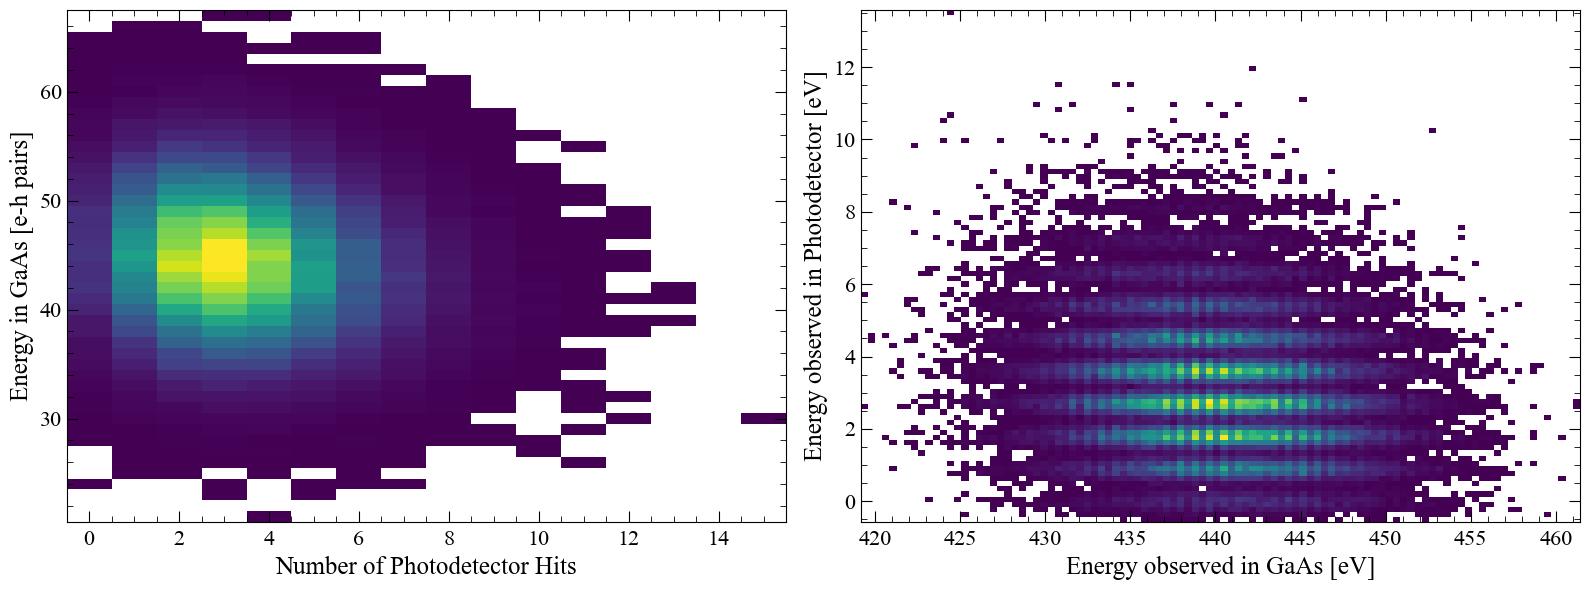

In [5]:
GaAs_band_gap = 1.5e-3  # Band gap energy in keV
GaAs_QE = 0.6 # Quantum efficiency of GaAs photodetector
GaAs_Fano = 0.12        # Fano factor
GaAs_gamma_energy = 0.9e-3  # Energy of recombined e-h photons in keV

def calculate_electron_hole_pairs(E_recoil, verbose=False):
    """
    Calculate the number of electron-hole pairs generated based on the recoil energy.

    Parameters:
        E_recoil (float): The recoil energy in keV.

    Returns:
        int: The number of electron-hole pairs generated.
    """
    # Constants

    if E_recoil < GaAs_band_gap:
        # If energy is less than the band gap, no electron-hole pairs are generated
        return 0
    elif GaAs_band_gap <= E_recoil <= 3 * GaAs_band_gap:
        # If energy is between the band gap and 3 times the band gap, return 1
        return 1
    else:
        # If energy is greater than 3 times the band gap, calculate the expected number of pairs
        N = E_recoil / (3 * GaAs_band_gap) / (1 - GaAs_Fano)
        p = 1 - GaAs_Fano
        if verbose:
            print(f'Expect mean number of pairs: {N*p:.03f}, variance: {N*p*(1-p):.03f}. This corresponds to N = {N:.03f}, p = {p:.03f}.')
        return generalized_binomial_sample(N, p)

collection_efficiency = 0.05 # v0 = 0.05, v1 = 0.21, v2 = 0.34
E_recoil = 0.5
E_res = 0.18e-3  # Resolution in keV
GaAs_res_ratio = np.sqrt(2)  # Resolution ratio for GaAs/Si
rng = np.random.default_rng(12345)

N_eh = np.zeros(100_000)
N_photons = np.zeros_like(N_eh)
N_photons_PD = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
N_eh_non_photon = np.zeros_like(N_eh)
E_PD_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)

for i in range(len(N_eh)):
    N_eh[i] = calculate_electron_hole_pairs(E_recoil, verbose=(True if i == 0 else False))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
    N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
    #N_photons_sink[i] = rng.binomial(N_photons[i], 1 - collection_efficiency)
    N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    N_eh_non_photon[i] = N_eh[i] - N_photons_PD[i] - N_photons_sink[i]

    E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
    E_GaAs_keV[i] = E_recoil - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
    
# Calculate the mean and variance of the number of pairs generated
print(f"Observed mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}")

# Plot the results in counts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

bins_PD = np.arange(min(N_photons_PD) - 0.5, max(N_photons_PD) + 1.5, 1)
bins_GaAs = np.arange(min(N_eh_non_photon) - 0.5, max(N_eh_non_photon) + 1.5, 1)
ax[0].hist2d(N_photons_PD, N_eh_non_photon, bins=(bins_PD, bins_GaAs), cmap='viridis', cmin=1)

ax[0].set_xlabel('Number of Photodetector Hits')
ax[0].set_ylabel('Energy in GaAs [e-h pairs]')

print(f'Number of Photodetector Hits: mu = {np.mean(N_photons_PD):.3f}, sigma = {np.var(N_photons_PD):.3f}')
print(f'Number of GaAs eh pairs: mu = {np.mean(N_eh_non_photon):.3f}, sigma = {np.var(N_eh_non_photon):.3f}')

# Plot the results in energy
ax[1].hist2d(E_GaAs_obs_keV*1e3, E_PD_keV*1e3, bins=(100, 100), cmap='viridis', cmin=1)
print(f'\nMeans: {np.mean(E_PD_keV)*1e3:.3f} eV in Photodetector, {np.mean(E_GaAs_obs_keV)*1e3:.3f} eV in GaAs')

ax[1].set_ylabel('Energy observed in Photodetector [eV]')
ax[1].set_xlabel('Energy observed in GaAs [eV]')
#fig.suptitle(f'E_recoil = {E_recoil} keV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=22)
#fig.title('Energy Distribution in Photodetector and GaAs')

fig.tight_layout()
fig.show()

### NR Signals

Expect mean number of pairs: 17.393, variance: 2.087. This corresponds to N = 19.764, p = 0.880.
Observed mean number of electron-hole pairs: 17.392, variance 2.238
Number of Photodetector Hits: mu = 2.090, sigma = 1.875
Number of GaAs eh pairs: mu = 6.950, sigma = 4.573

Means: 1.881 eV in Photodetector, 490.601 eV in GaAs


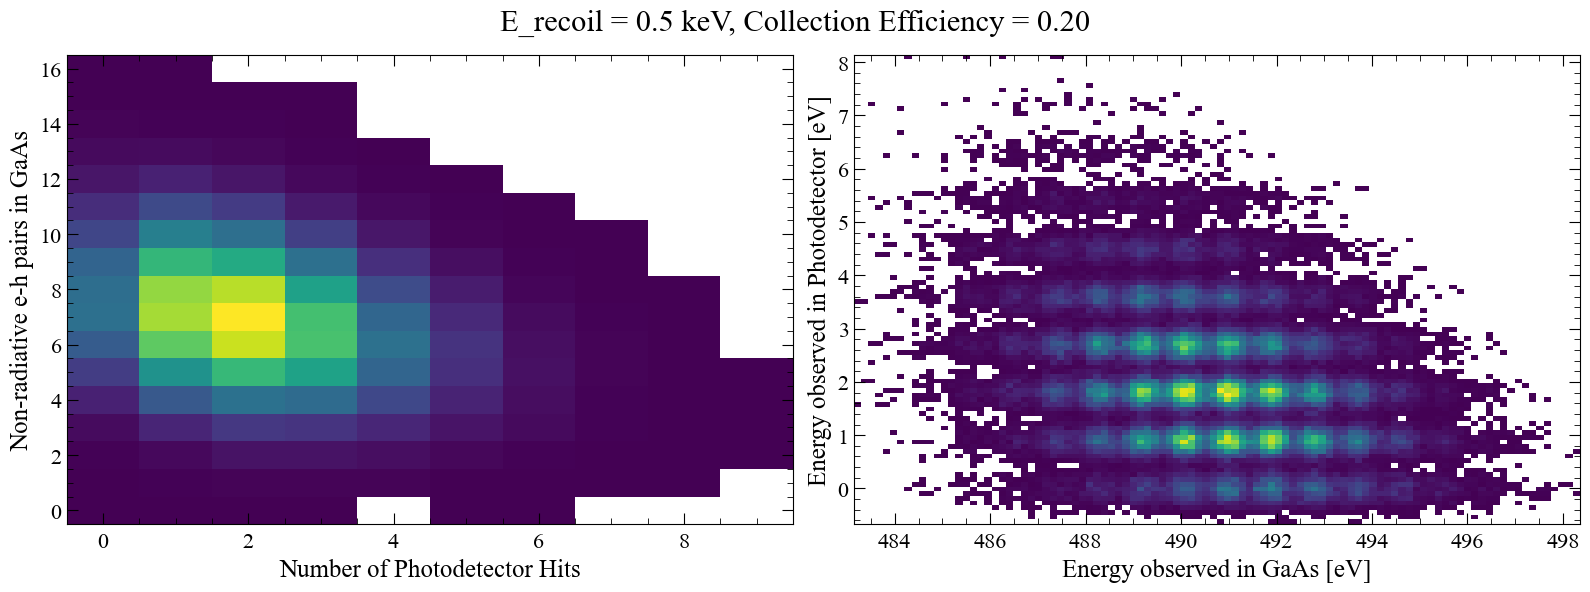

In [6]:
E_recoil_NR = 0.5
collection_efficiency = 0.20 # v0 = 0.05, v1 = 0.21, v2 = 0.34

N_eh = np.zeros(100_000)
N_photons = np.zeros_like(N_eh)
N_photons_PD = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
N_eh_non_photon = np.zeros_like(N_eh)
E_PD_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)

for i in range(len(N_eh)):
    N_eh[i] = calculate_electron_hole_pairs(E_recoil_NR * Lindhard(E_recoil_NR), verbose=(True if i == 0 else False))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
    N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
    #N_photons_sink[i] = rng.binomial(N_photons[i], 1 - collection_efficiency)
    N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    N_eh_non_photon[i] = N_eh[i] - N_photons_PD[i] - N_photons_sink[i]

    E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
    E_GaAs_keV[i] = E_recoil_NR - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
    
# Calculate the mean and variance of the number of pairs generated
print(f"Observed mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}")

# Plot the results in counts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

bins_PD = np.arange(min(N_photons_PD) - 0.5, max(N_photons_PD) + 1.5, 1)
bins_GaAs = np.arange(min(N_eh_non_photon) - 0.5, max(N_eh_non_photon) + 1.5, 1)
ax[0].hist2d(N_photons_PD, N_eh_non_photon, bins=(bins_PD, bins_GaAs), cmap='viridis', cmin=1)

ax[0].set_xlabel('Number of Photodetector Hits')
ax[0].set_ylabel('Non-radiative e-h pairs in GaAs')

print(f'Number of Photodetector Hits: mu = {np.mean(N_photons_PD):.3f}, sigma = {np.var(N_photons_PD):.3f}')
print(f'Number of GaAs eh pairs: mu = {np.mean(N_eh_non_photon):.3f}, sigma = {np.var(N_eh_non_photon):.3f}')

# Plot the results in energy
ax[1].hist2d(E_GaAs_obs_keV*1e3, E_PD_keV*1e3, bins=(100, 100), cmap='viridis', cmin=1)
print(f'\nMeans: {np.mean(E_PD_keV)*1e3:.3f} eV in Photodetector, {np.mean(E_GaAs_obs_keV)*1e3:.3f} eV in GaAs')

ax[1].set_ylabel('Energy observed in Photodetector [eV]')
ax[1].set_xlabel('Energy observed in GaAs [eV]')
fig.suptitle(f'E_recoil = {E_recoil_NR} keV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=22)
#fig.title('Energy Distribution in Photodetector and GaAs')

fig.tight_layout()
fig.show()

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

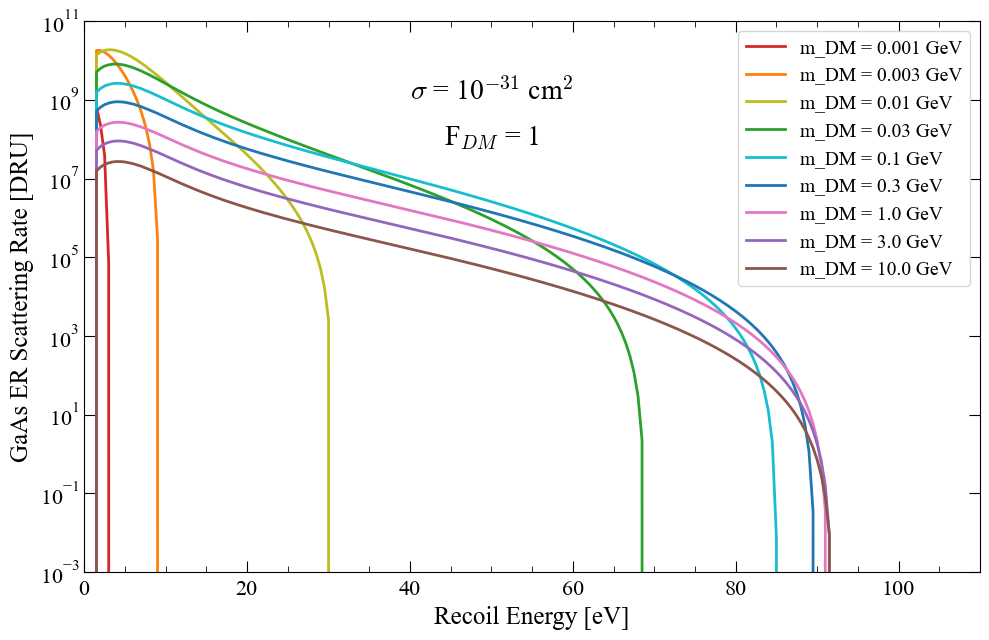

In [7]:
E_keV = np.linspace(0.5e-3, 100e-3, 200)
fig, ax = plt.subplots(figsize=(10, 6.5))

for mX, color in zip([1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10],
    ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
    
    fun = darklim.elf.get_dRdE_lambda_GaAs_electron(mX_eV=mX, mediator='massive', sigmae=1e-31)
    dRdE = [fun(E) for E in E_keV]

    ax.plot(E_keV * 1e3, dRdE, label=f'm_DM = {mX / 1e9} GeV', color=color)

ax.text(50, 1e9, r'$\sigma$ = 10$^{-31}$ cm$^2$', fontsize=20, color='black', ha='center')
ax.text(50, 7e7, r'F$_{DM}$ = 1', fontsize=20, color='black', ha='center')

ax.set_xlabel('Recoil Energy [eV]')
ax.set_ylabel('GaAs ER Scattering Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-3, 1e11])
ax.set_xlim([0, 110])
ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()


 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

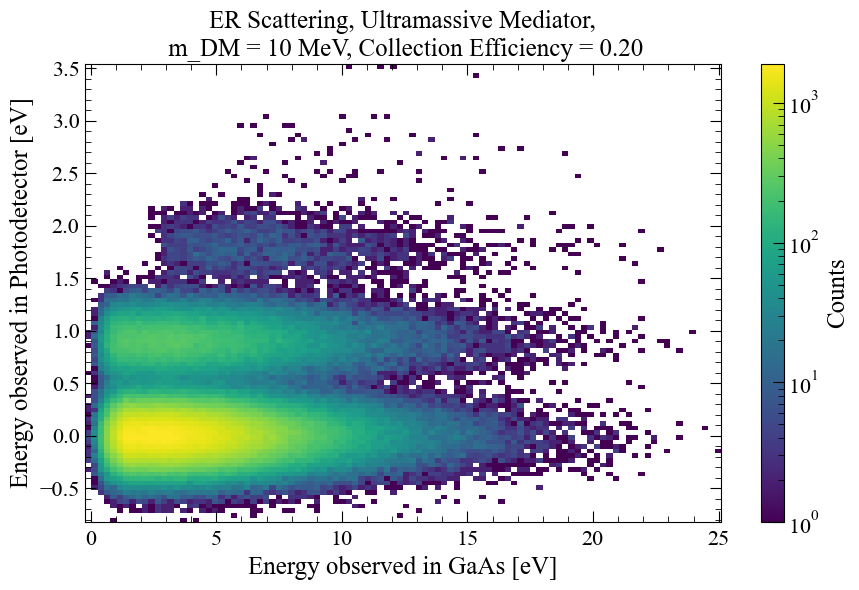

In [8]:
E_DM_keV = np.linspace(0.5e-3, 100e-3, 400)
mX_eV = 10e6
    
fun = darklim.elf.get_dRdE_lambda_GaAs_electron(mX_eV=mX_eV, mediator='massive', sigmae=1e-31)
dRdE_DM_DRU = [fun(E) for E in E_DM_keV]
pdf_DM = np.array(dRdE_DM_DRU) / np.trapz(dRdE_DM_DRU, E_DM_keV)
cdf_DM = np.cumsum(pdf_DM) * (E_DM_keV[1] - E_DM_keV[0])

########################

collection_efficiency = 0.20 # v0 = 0.05, v1 = 0.21, v2 = 0.34
E_res = 0.18e-3  # Resolution in keV
GaAs_res_ratio = np.sqrt(2)  # Resolution ratio for GaAs/Si
rng = np.random.default_rng(12345)

E_recoil = np.zeros(500_000, dtype=float)
for i in range(len(E_recoil)):
    p = rng.random()
    E_recoil[i] = np.interp(p, cdf_DM, E_DM_keV)

N_eh = np.zeros_like(E_recoil)
N_photons = np.zeros_like(N_eh)
N_photons_PD = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
N_eh_non_photon = np.zeros_like(N_eh)
E_PD_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)

for i in range(len(N_eh)):
    N_eh[i] = calculate_electron_hole_pairs(E_recoil[i], verbose=(True if i == 0 else False))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
    N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
    #N_photons_sink[i] = rng.binomial(N_photons[i], 1 - collection_efficiency)
    N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    N_eh_non_photon[i] = N_eh[i] - N_photons_PD[i] - N_photons_sink[i]

    E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
    E_GaAs_keV[i] = E_recoil[i] - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
    
# Calculate the mean and variance of the number of pairs generated
print(f"Observed mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}")

# Plot the results in counts
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

# Plot the results in energy
h = ax.hist2d(E_GaAs_obs_keV*1e3, E_PD_keV*1e3, bins=(100, 100), norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax, label='Counts')

print(f'\nMeans: {np.mean(E_PD_keV)*1e3:.3f} eV in Photodetector, {np.mean(E_GaAs_obs_keV)*1e3:.3f} eV in GaAs')
print(f'Fraction of events with at least 0.9 eV in Photodetector: {np.sum(E_PD_keV > 0.9e-3) / len(E_PD_keV):.3f}')

ax.set_ylabel('Energy observed in Photodetector [eV]')
ax.set_xlabel('Energy observed in GaAs [eV]')
ax.set_title(f'ER Scattering, Ultramassive Mediator,\n m_DM = {mX_eV/1e6:.0f} MeV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=18)

fig.tight_layout()
fig.show()

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

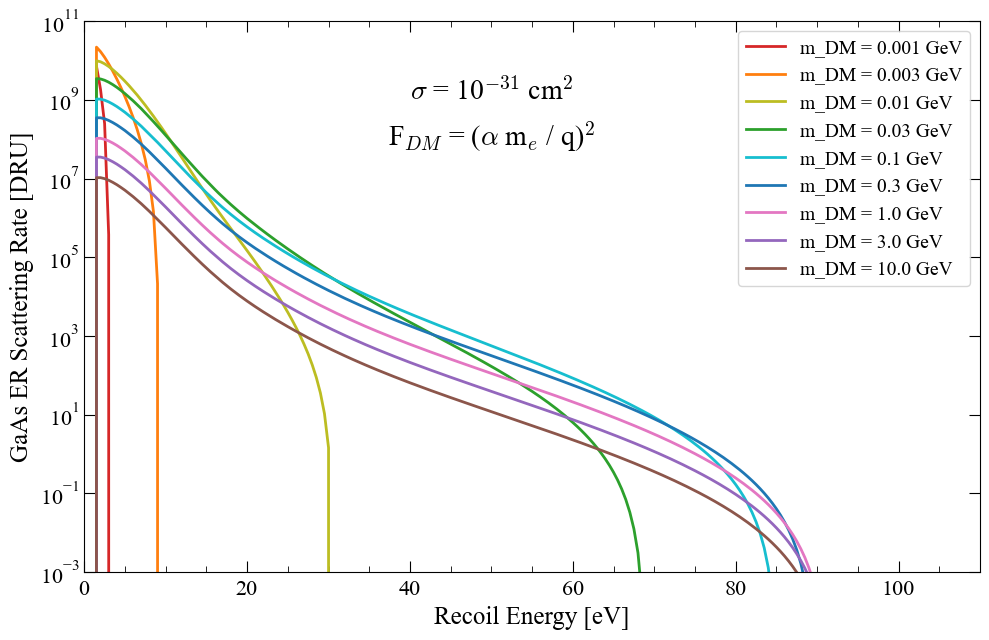

In [9]:
E_keV = np.linspace(0.5e-3, 100e-3, 200)
fig, ax = plt.subplots(figsize=(10, 6.5))

for mX, color in zip([1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10],
    ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
    
    fun = darklim.elf.get_dRdE_lambda_GaAs_electron(mX_eV=mX, mediator='massless', sigmae=1e-31)
    dRdE = [fun(E) for E in E_keV]

    ax.plot(E_keV * 1e3, dRdE, label=f'm_DM = {mX / 1e9} GeV', color=color)

ax.text(50, 1e9, r'$\sigma$ = 10$^{-31}$ cm$^2$', fontsize=20, color='black', ha='center')
ax.text(50, 7e7, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$',fontsize=20, color='black', ha='center')

ax.set_xlabel('Recoil Energy [eV]')
ax.set_ylabel('GaAs ER Scattering Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-3, 1e11])
ax.set_xlim([0, 110])
ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()


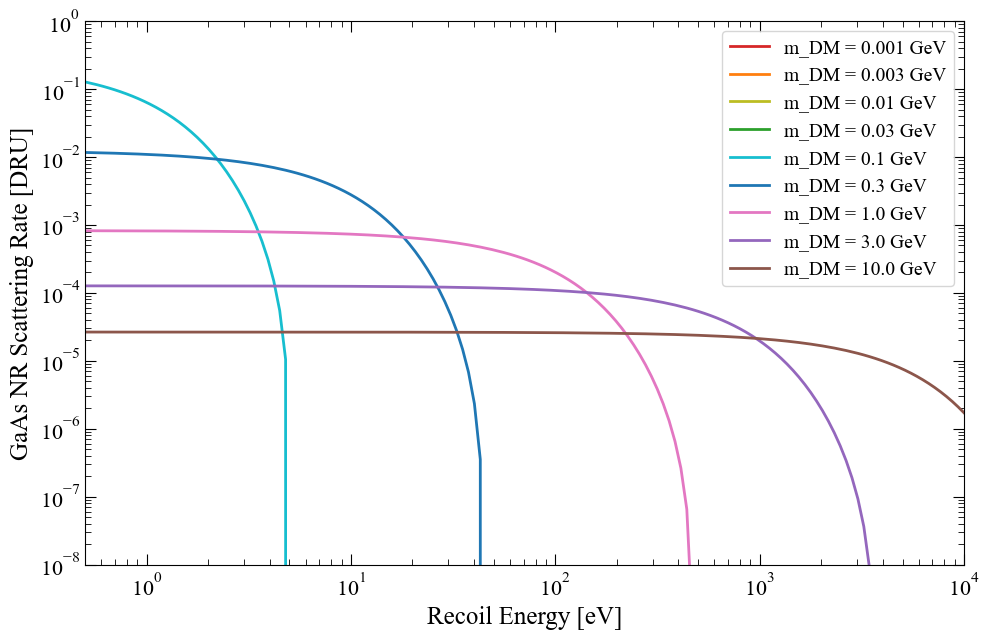

In [10]:
E_keV = np.geomspace(0.5e-3, 10, 150)
fig, ax = plt.subplots(figsize=(10, 6.5))

for i, (mX, color) in enumerate(zip([1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10],
    ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):

    dRdE_arr = darklim.limit._limit.drde(E_keV, mX/1e9, 1e-45, 'Si')
    ax.plot(E_keV * 1e3, dRdE_arr, label=f'm_DM = {mX / 1e9} GeV', color=color)

#ax.text(50, 1e9, r'$\sigma$ = 10$^{-31}$ cm$^2$', fontsize=20, color='black', ha='center')

ax.set_xlabel('Recoil Energy [eV]')
ax.set_ylabel('GaAs NR Scattering Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-8, 1e0])
ax.set_xscale('log')
ax.set_xlim([E_keV[0] * 1e3, E_keV[-1] * 1e3])
ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()


 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


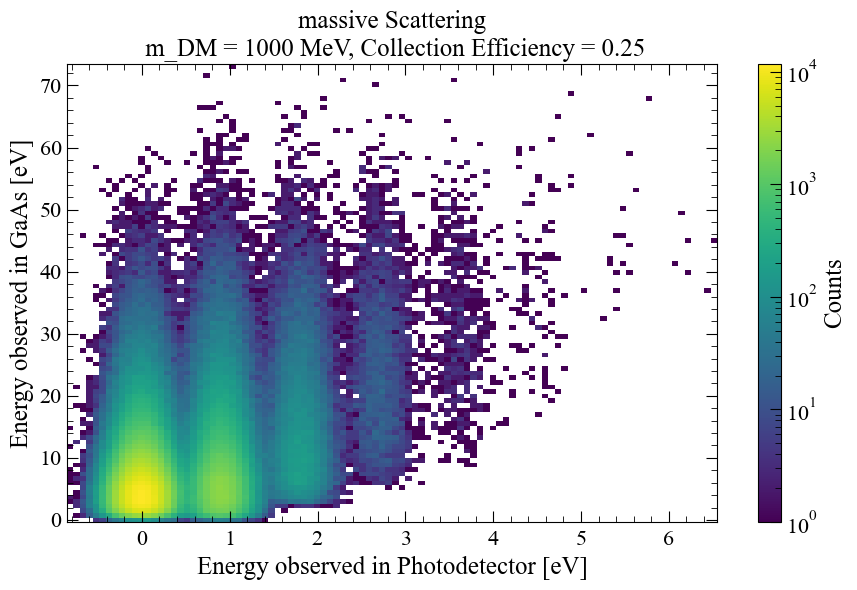

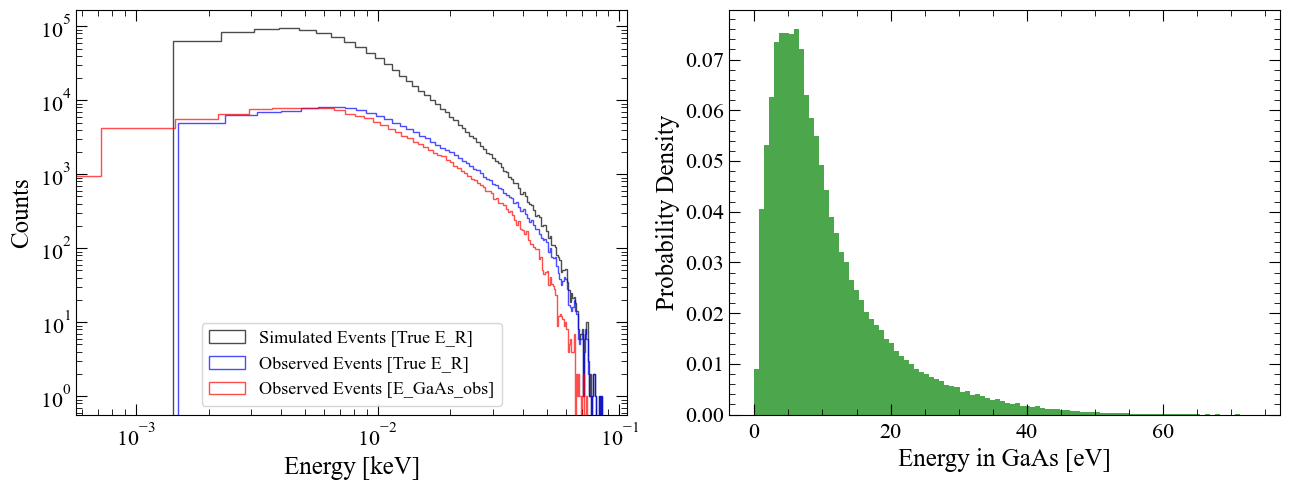

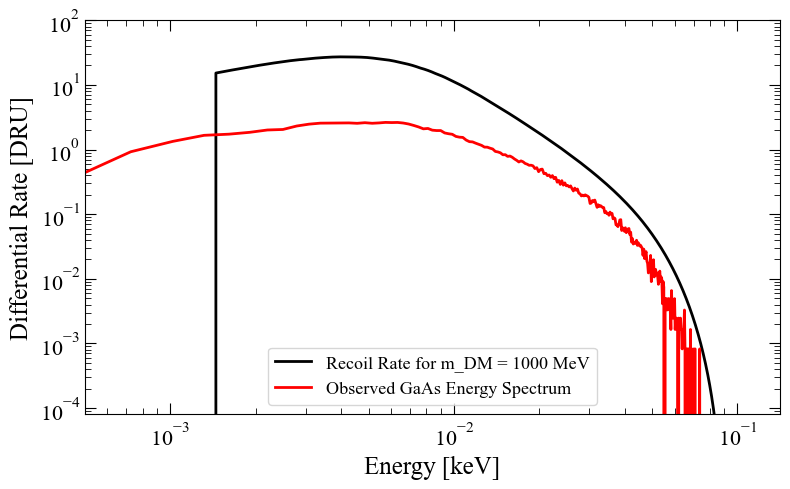

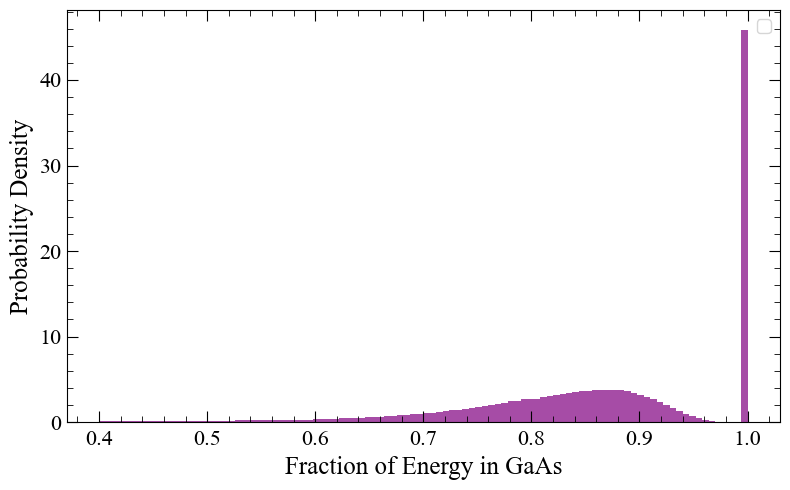

In [ ]:
collection_efficiency = 0.25 # v0 = 0.05, v1 = 0.21, v2 = 0.34
E_res = 0.18e-3  # Resolution in keV
GaAs_res_ratio = np.sqrt(2)  # Resolution ratio for GaAs/Si
rng = np.random.default_rng()

def DM_spectrum_GaAs(m_DM_eV, sigma, rng, mediator='NR', E_th_PD=0.9e-3, verbose=False, plot=False):
    """ 
    Generate the DM spectrum for GaAs based on the given mass and cross-section.
    
    Parameters:
        m_DM_eV (float): Mass of the dark matter particle in eV.
        sigma (float): Cross-section for nuclear or electron scattering in cm^2.
        
    Returns:
        tuple: Energy array in keV and corresponding differential rate.
    """

    if mediator == 'NR':
        E_DM_keV = np.geomspace(0.5e-3, 50, 400)
        dRdE_DM_DRU = darklim.limit.drde(E_DM_keV, m_DM_eV/1e9, sigma, 'GaAs')

    else:
        E_DM_keV = np.append(np.linspace(0.1e-3, 3e-3, 100), np.linspace(3e-3, 100e-3, 400))
        fun = darklim.elf.get_dRdE_lambda_GaAs_electron(mX_eV=m_DM_eV, mediator=mediator, sigmae=sigma)
        dRdE_DM_DRU = [fun(E) for E in E_DM_keV]

    R_integrated = np.trapz(dRdE_DM_DRU, E_DM_keV)
    pdf_DM = np.array(dRdE_DM_DRU) / R_integrated  # Normalize the differential rate to get a PDF
    cdf_DM = np.cumsum(pdf_DM * np.append(np.array([0.]), np.diff(E_DM_keV)))
    cdf_DM /= cdf_DM[-1]  # Normalize to end at 1

    ########################
    
    n_sim = 1_000_000  # Number of simulated events
    E_recoil = np.zeros(n_sim, dtype=float)
    for i in range(len(E_recoil)):
        p = rng.random()
        E_recoil[i] = np.interp(p, cdf_DM, E_DM_keV)

    N_eh = np.zeros_like(E_recoil)
    N_photons = np.zeros_like(N_eh)
    N_photons_PD = np.zeros_like(N_eh)
    N_photons_sink = np.zeros_like(N_eh)
    E_PD_keV = np.zeros_like(N_eh)
    E_GaAs_keV = np.zeros_like(N_eh)
    E_GaAs_obs_keV = np.zeros_like(N_eh)
    fraction_in_GaAs = np.zeros_like(N_eh)
    detected = np.zeros_like(N_eh, dtype=bool)

    for i in range(len(N_eh)):
        if mediator == 'NR':
            N_eh[i] = calculate_electron_hole_pairs(E_recoil[i] * Lindhard(E_recoil[i]))
        else:
            N_eh[i] = calculate_electron_hole_pairs(E_recoil[i])

        N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
        N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
        N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    
        E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
        E_GaAs_keV[i] = E_recoil[i] - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
        E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
        
        fraction_in_GaAs[i] = E_GaAs_keV[i] / E_recoil[i] if E_recoil[i] > 0 else 0
        detected[i] = E_PD_keV[i] > E_th_PD

    fraction_detected = sum(detected) / n_sim

    if sum(detected) == 0:
        return E_DM_keV, np.zeros_like(dRdE_DM_DRU)
        
    # Convert simulation to dRdE spectrum for GaAs observed energy
    E_GaAs_bins = np.linspace(min(E_GaAs_obs_keV[detected]) * 0.8, max(E_GaAs_obs_keV[detected]) * 1.2, 300)
    dRdE_GaAs_obs, _ = np.histogram(E_GaAs_obs_keV[detected], bins=E_GaAs_bins, density=True)
    E_GaAs_bins = (E_GaAs_bins[:-1] + E_GaAs_bins[1:]) / 2  # Convert to bin centers
    dRdE_GaAs_obs *= fraction_detected * R_integrated

    if verbose:
        print(f'Mean recoil energy: {np.mean(E_recoil)*1e3:.3f} eV, std {np.std(E_recoil)*1e3:.3f} eV')
        print(f'Mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}')
        print(f'Fraction of events with at least {E_th_PD*1e3:.2f} eV in Photodetector: {fraction_detected:.3f}')

    if plot:

        # Plot the results in counts
        fig, ax = plt.subplots(1, 1, figsize=(9, 6))
        
        h = ax.hist2d(E_PD_keV*1e3, E_GaAs_obs_keV*1e3, bins=(100, 100), norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
        fig.colorbar(h[3], ax=ax, label='Counts')
        
        ax.set_xlabel('Energy observed in Photodetector [eV]')
        ax.set_ylabel('Energy observed in GaAs [eV]')
        ax.set_title(f'{mediator} Scattering\n m_DM = {m_DM_eV/1e6:.0f} MeV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=18)
        
        fig.tight_layout()
        fig.show()

        # Plot the distribution of recoil energies that trigger the photodetector
        fig, ax = plt.subplots(1, 2, figsize=(13, 5))
        ax[0].hist(E_recoil, bins=100, alpha=0.7, histtype='step', color='black', label='Simulated Events [True E_R]')
        ax[0].hist(E_recoil[detected], bins=100, alpha=0.7, histtype='step', color='blue', label='Observed Events [True E_R]')
        ax[0].hist(E_GaAs_obs_keV[detected], bins=100, alpha=0.7, histtype='step', color='red', label='Observed Events [E_GaAs_obs]')
        ax[0].set_xscale('log')
        ax[0].set_yscale('log')
        xmin, xmax = ax[0].get_xlim()
        ax[0].set_xlim([max(1e-4, xmin), xmax])
        ax[0].set_xlabel('Energy [keV]')
        ax[0].set_ylabel('Counts')
        ax[0].legend(loc='best', fontsize=13)

        # Plot the distribution of energy in GaAs if there is at least 0.9 eV in the Photodetector
        ax[1].hist(E_GaAs_obs_keV[detected] * 1e3, bins=100, density=True, alpha=0.7, color='green')
        ax[1].set_xlabel('Energy in GaAs [eV]')
        ax[1].set_ylabel('Probability Density')
        fig.tight_layout()
        fig.show()

        # Plot the differential rate in GaAs observed energy
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(E_DM_keV, dRdE_DM_DRU, label=f'Recoil Rate for m_DM = {m_DM_eV/1e6:.0f} MeV', color='black')
        ax.plot(E_GaAs_bins, dRdE_GaAs_obs, label=f'Observed GaAs Energy Spectrum', color='red')
        ax.set_xlabel('Energy [keV]')
        ax.set_ylabel('Differential Rate [DRU]')
        ax.set_xscale('log')
        ax.set_yscale('log')
        xmin, xmax = ax.get_xlim()
        ax.set_xlim([max(5e-4, xmin), xmax])
        ymin, ymax = ax.get_ylim()
        ax.set_ylim([min(dRdE_GaAs_obs[dRdE_GaAs_obs > 0]) / 10, ymax])
        ax.legend(loc='best', fontsize=13)
        fig.tight_layout()
        fig.show()

        # Plot the fraction of energy in GaAs
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(fraction_in_GaAs, bins=100, density=True, alpha=0.7, color='purple')
        ax.set_xlabel('Fraction of Energy in GaAs')
        ax.set_ylabel('Probability Density')
        ax.legend(loc='best', fontsize=13)
        fig.tight_layout()
        fig.show()


    return E_GaAs_bins, dRdE_GaAs_obs

DM_spectrum_GaAs(1e9, 1e-38, rng, mediator='massive', plot=True, verbose=True);

# Signal Detection Efficiency vs Energy (Also see GaAs_Development_2.ipynb)

Finished ER, 2-fold, LCE = 0.10
Finished ER, 2-fold, LCE = 0.30
Finished ER, 2-fold, LCE = 0.50
Finished ER, 3-fold, LCE = 0.10
Finished ER, 3-fold, LCE = 0.30
Finished ER, 3-fold, LCE = 0.50
Finished NR, 2-fold, LCE = 0.10
Finished NR, 2-fold, LCE = 0.30
Finished NR, 2-fold, LCE = 0.50
Finished NR, 3-fold, LCE = 0.10
Finished NR, 3-fold, LCE = 0.30
Finished NR, 3-fold, LCE = 0.50


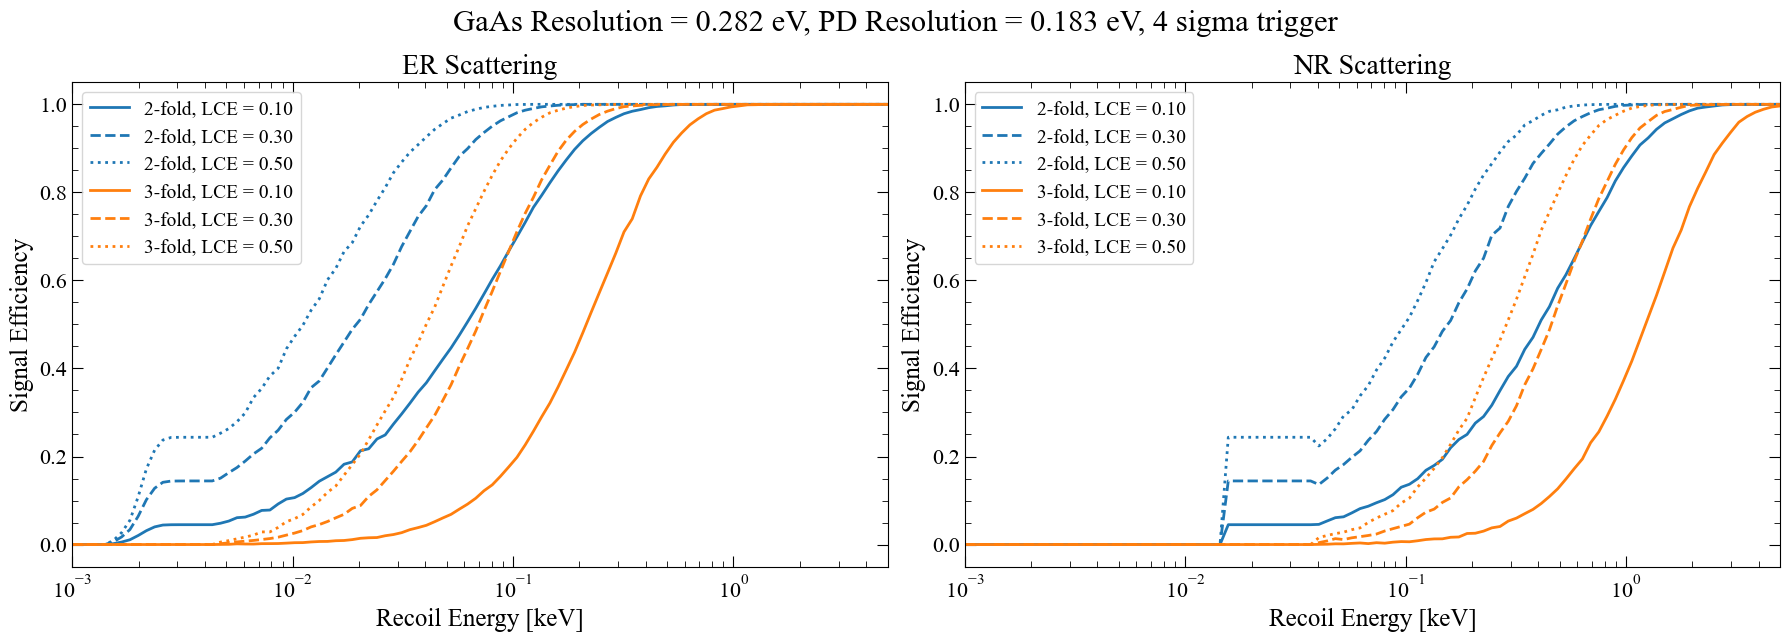

In [2]:
# Probably not changing these
GaAs_QE = 0.6
GaAs_gamma_energy = 0.9e-3  # Energy of recombined e-h photons in keV

# Containers to hold signal efficiency
E_keV_arr = np.geomspace(0.001, 5, 100)

# We may want to change these
GaAs_energy_resolution = 0.282e-3  # Energy resolution in keV
PD_energy_resolution = 0.183e-3 
n_sigma = 4.0

fig, ax = plt.subplots(1, 2, figsize=(18, 6.5))

for axi, pt in enumerate(['ER', 'NR']):
    for fold, color in zip([2, 3], ['C0', 'C1']):
        for LCE, ls in zip([0.1, 0.3, 0.5], ['-', '--', ':']):
            
            eps_arr = np.zeros_like(E_keV_arr)
            label = f'{fold}-fold, LCE = {LCE:.2f}'

            for i, E_keV in enumerate(E_keV_arr):

                E_GaAs_obs_keV, E_PD_A_obs_keV, E_PD_B_obs_keV, detected = \
                    darklim.detector.monoenergetic_sim_GaAs(
                        E_keV, recoil = pt, N_PDs = (fold - 1),
                        E_th_PD = PD_energy_resolution * n_sigma, E_res_PD = PD_energy_resolution,
                        E_th_GaAs = GaAs_energy_resolution * n_sigma, E_res_GaAs = GaAs_energy_resolution,
                        collection_efficiency=LCE, GaAs_QE=GaAs_QE, GaAs_gamma_energy=GaAs_gamma_energy,
                        rng=np.random.default_rng(12345), n_sim = 10_000, verbose=False
                    )

                eps_arr[i] = np.sum(detected) / len(detected)

            ax[axi].plot(E_keV_arr, eps_arr, label=label, color=color, ls=ls)
            print(f'Finished {pt}, {label}')

ax[0].set_xlabel('Recoil Energy [keV]')
ax[0].set_ylabel('Signal Efficiency')
ax[0].set_title('ER Scattering')
ax[0].set_xscale('log')
ax[0].legend(loc='upper left', fontsize=14)
ax[0].set_xlim([E_keV_arr[0], E_keV_arr[-1]])

ax[1].set_xlabel('Recoil Energy [keV]')
ax[1].set_ylabel('Signal Efficiency')
ax[1].set_title('NR Scattering')
ax[1].set_xscale('log')
ax[1].legend(loc='upper left', fontsize=14)
ax[1].set_xlim([E_keV_arr[0], E_keV_arr[-1]])

fig.suptitle(f'GaAs Resolution = {GaAs_energy_resolution*1e3:.3f} eV, PD Resolution = {PD_energy_resolution*1e3:.3f} eV, {n_sigma:.0f} sigma trigger', fontsize=22)

fig.tight_layout()
fig.show()


In [14]:
E_GaAs_obs_keV, E_PD_A_obs_keV, E_PD_B_obs_keV, detected = \
    darklim.detector.monoenergetic_sim_GaAs(
        0.020, recoil = 'NR', N_PDs = 2,
        E_th_PD = PD_energy_resolution * n_sigma, E_res_PD = PD_energy_resolution,
        E_th_GaAs = GaAs_energy_resolution * n_sigma, E_res_GaAs = GaAs_energy_resolution,
        collection_efficiency=0.5, GaAs_QE=GaAs_QE, GaAs_gamma_energy=GaAs_gamma_energy,
        rng=np.random.default_rng(12345), n_sim = 10_000, verbose=False
    )

print(np.sum(detected) / len(detected))

# N_eh = np.zeros(100_000)
# for i in range(len(N_eh)):
#     N_eh[i] = darklim.detector.calculate_electron_hole_pairs(0.020 * Lindhard(0.020))
# print(np.histogram(N_eh, bins=np.arange(-0.5, 4.5)))

0.0


In [15]:
E_recoil = np.full(10_000, E_keV, dtype=float)
rng=np.random.default_rng(12345)

N_eh = np.zeros_like(E_recoil)
N_photons = np.zeros_like(N_eh)
N_photons_PD_A = np.zeros_like(N_eh)
N_photons_PD_B = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
E_PD_A_keV = np.zeros_like(N_eh)
E_PD_B_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)
fraction_in_GaAs = np.zeros_like(N_eh)
detected = np.zeros_like(N_eh, dtype=bool)

for i in range(len(N_eh)):

    N_eh[i] = darklim.detector.calculate_electron_hole_pairs(E_recoil[i] * Lindhard(E_recoil[i]))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)

    N_photons_PD_A[i] = rng.binomial(N_photons[i], 0.50/2)
    N_photons_PD_B[i] = rng.binomial(N_photons[i], 0.50/2)
    N_photons_sink[i] = N_photons[i] - (N_photons_PD_A[i] + N_photons_PD_B[i])

    E_PD_A_keV[i] = rng.normal(N_photons_PD_A[i] * GaAs_gamma_energy, E_res_PD)
    E_PD_B_keV[i] = rng.normal(N_photons_PD_B[i] * GaAs_gamma_energy, E_res_PD)
    
    E_GaAs_keV[i] = E_recoil[i] - (N_photons_PD_A[i] + N_photons_PD_B[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res_GaAs)

    fraction_in_GaAs[i] = E_GaAs_keV[i] / E_recoil[i] if E_recoil[i] > 0 else 0
    detected[i] = (E_PD_A_keV[i] > E_th_PD) * (E_PD_B_keV[i] > E_th_PD) * (E_GaAs_obs_keV[i] > E_th_GaAs)



print(np.histogram(N_eh, bins=np.arange(-0.5, 4.5))[0])


NameError: name 'E_res_PD' is not defined

# Trigger Efficiency

In [2]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))

### Background parameters
rate_Hz = 100  # Event rate in Hz (for the simulation--this should be as high as possible without inducing pileup)

### Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
desired_energy_resolution = 0.200
n_sigma = 4.0  # Number of sigma for the trigger

template_OF = np.copy(templates_td)
csd_OF = np.copy(csd) * (desired_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


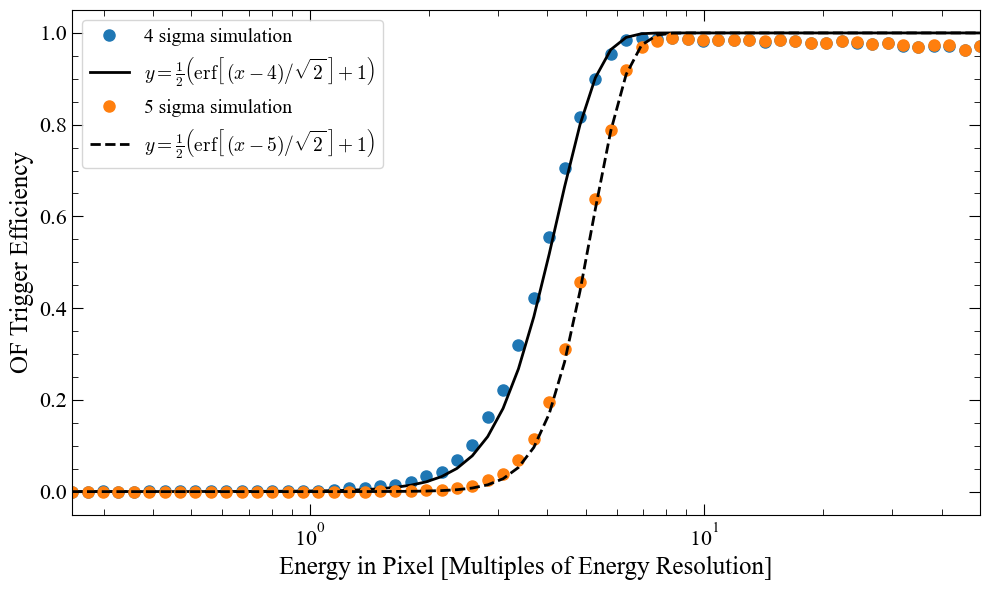

In [3]:
E_keV_arr = np.geomspace(0.05, 10, 60)
eps_arr = np.zeros_like(E_keV_arr)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for n_sigma, ls in zip([4., 5.], ['-', '--']):
    for i, E_keV in enumerate(E_keV_arr):

        trigger_times, trigger_amplitudes, true_arrival_times, detected, sim_ids = \
            darklim.detector.monoenergetic_sim_OF(template_OF, csd_OF, fs, E_keV, n_sims=5_000, rate_Hz=25., n_sigma=n_sigma, seed=3941 + i*13, n_cores=10)
        eps_arr[i] = np.sum(detected) / len(detected)

    ax.plot(E_keV_arr / desired_energy_resolution, eps_arr, 'o', ms=8, label=f'{n_sigma:.0f} sigma simulation')
    x_model = E_keV_arr / desired_energy_resolution
    y_model = 0.5 * (erf((x_model - n_sigma) / np.sqrt(2)) + 1)
    label = r'$y = \frac{1}{2} \left( \text{erf} \left[\, (x - %0d) / \sqrt{2}\, \right] + 1 \right)$' % n_sigma
    ax.plot(x_model, y_model, color='k', ls=ls, lw=2, label=label)
    if i % 5 == 0:
        print(f'Finished {i} of {len(E_keV_arr)}')

ax.set_xlabel('Energy in Pixel [Multiples of Energy Resolution]')
ax.set_ylabel('OF Trigger Efficiency')
ax.set_xscale('log')
ax.set_xlim([E_keV_arr[0] / desired_energy_resolution, E_keV_arr[-1] / desired_energy_resolution])
ax.legend(loc='upper left', fontsize=14)

fig.tight_layout()
fig.show()

[0.00000000e+00 6.02409639e-04 3.52941176e-03 7.29335494e-02
 8.52300740e-01]
[0.         0.         0.         0.00931929 0.53327855]


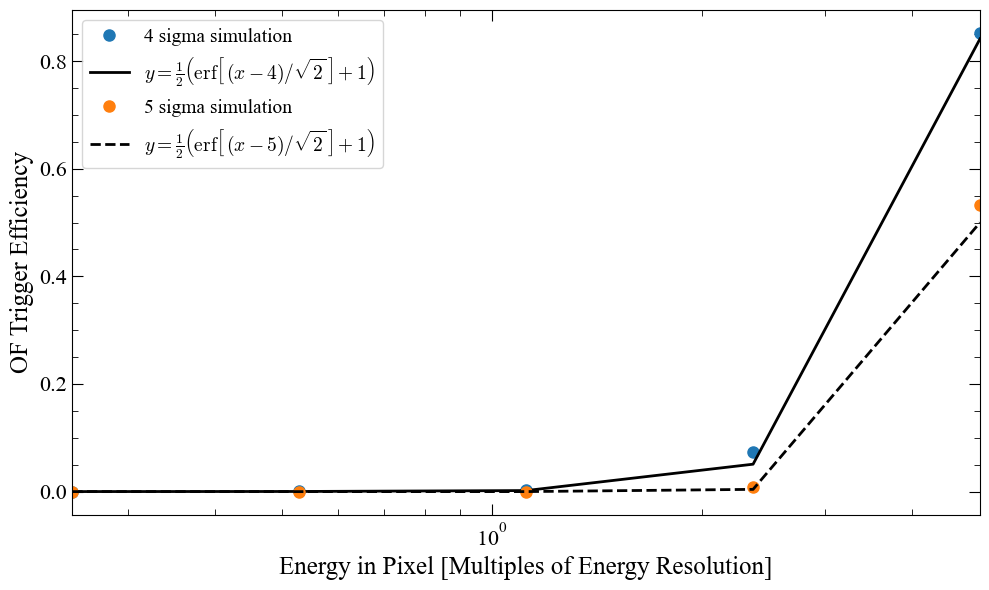

In [6]:
E_keV_arr = np.geomspace(0.05, 1, 5)
eps_arr = np.zeros_like(E_keV_arr)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for n_sigma, ls in zip([4., 5.], ['-', '--']):
    for i, E_keV in enumerate(E_keV_arr):

        trigger_times, trigger_amplitudes, true_arrival_times, detected, sim_ids = \
            darklim.detector.monoenergetic_sim_OF(template_OF, csd_OF, fs, E_keV, n_sims=5_000, rate_Hz=25., n_sigma=n_sigma, seed=3941 + i*13, n_cores=10)
        eps_arr[i] = np.sum(detected) / len(detected)

    ax.plot(E_keV_arr / desired_energy_resolution, eps_arr, 'o', ms=8, label=f'{n_sigma:.0f} sigma simulation')
    x_model = E_keV_arr / desired_energy_resolution
    y_model = 0.5 * (erf((x_model - n_sigma) / np.sqrt(2)) + 1)
    label = r'$y = \frac{1}{2} \left( \text{erf} \left[\, (x - %0d) / \sqrt{2}\, \right] + 1 \right)$' % n_sigma
    ax.plot(x_model, y_model, color='k', ls=ls, lw=2, label=label)
    if i % 5 == 0:
        print(f'Finished {i} of {len(E_keV_arr)}')

    print(eps_arr)

ax.set_xlabel('Energy in Pixel [Multiples of Energy Resolution]')
ax.set_ylabel('OF Trigger Efficiency')
ax.set_xscale('log')
ax.set_xlim([E_keV_arr[0] / desired_energy_resolution, E_keV_arr[-1] / desired_energy_resolution])
ax.legend(loc='upper left', fontsize=14)

fig.tight_layout()
fig.show()

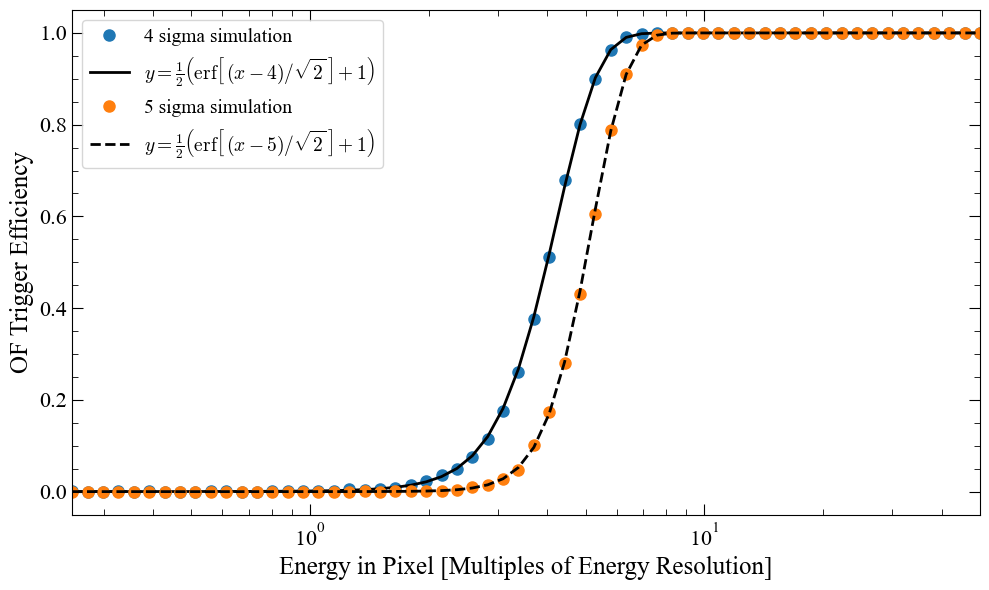

In [5]:
E_keV_arr = np.geomspace(0.05, 10, 60)
eps_arr = np.zeros_like(E_keV_arr)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for n_sigma, ls in zip([4., 5.], ['-', '--']):
    for i, E_keV in enumerate(E_keV_arr):

        trigger_amplitudes = np.random.normal(E_keV, desired_energy_resolution, 5_000)
        eps_arr[i] = np.sum(trigger_amplitudes > n_sigma * desired_energy_resolution) / len(trigger_amplitudes)

    ax.plot(E_keV_arr / desired_energy_resolution, eps_arr, 'o', ms=8, label=f'{n_sigma:.0f} sigma simulation')
    x_model = E_keV_arr / desired_energy_resolution
    y_model = 0.5 * (erf((x_model - n_sigma) / np.sqrt(2)) + 1)
    label = r'$y = \frac{1}{2} \left( \text{erf} \left[\, (x - %0d) / \sqrt{2}\, \right] + 1 \right)$' % n_sigma
    ax.plot(x_model, y_model, color='k', ls=ls, lw=2, label=label)
    if i % 5 == 0:
        print(f'Finished {i} of {len(E_keV_arr)}')

ax.set_xlabel('Energy in Pixel [Multiples of Energy Resolution]')
ax.set_ylabel('OF Trigger Efficiency')
ax.set_xscale('log')
ax.set_xlim([E_keV_arr[0] / desired_energy_resolution, E_keV_arr[-1] / desired_energy_resolution])
ax.legend(loc='upper left', fontsize=14)

fig.tight_layout()
fig.show()

# Optimum Filter Analytical Coincidence (Rho Function)

In [ ]:
# Load template
template = detprocess.Template(verbose=True)

template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')
channel = 'Mv3025pcBigFinsLeft'

templates_td, t_sec_template, _ = template.get_template(channel, return_metadata=True, tag='single')

csd, freqs_csd, _ = template.get_psd(channel, fold=False, return_metadata=True, tag='default')
n_channels = m_amplitudes = 1
f_frequencies = templates_td.shape[0]

INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
fs = 1.25e6  # Sampling frequency in Hz

# Background Distribution Parameters
rate_Hz = 50                  # event rate in Hz
lambda_E = 1 / 5.0             # decay constant for energy in 1/eV


In [ ]:
oftrigger_1x1 = detprocess.OptimumFilterTrigger('MyTrigger', fs, templates_td, csd, pretrigger_samples=int(f_frequencies/2))

delta_t_arr = np.arange(-1000, 1001)
rho_arr = np.zeros_like(delta_t_arr, dtype=float)
for i, delta_t in enumerate(delta_t_arr):
    rho_arr[i] = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t)


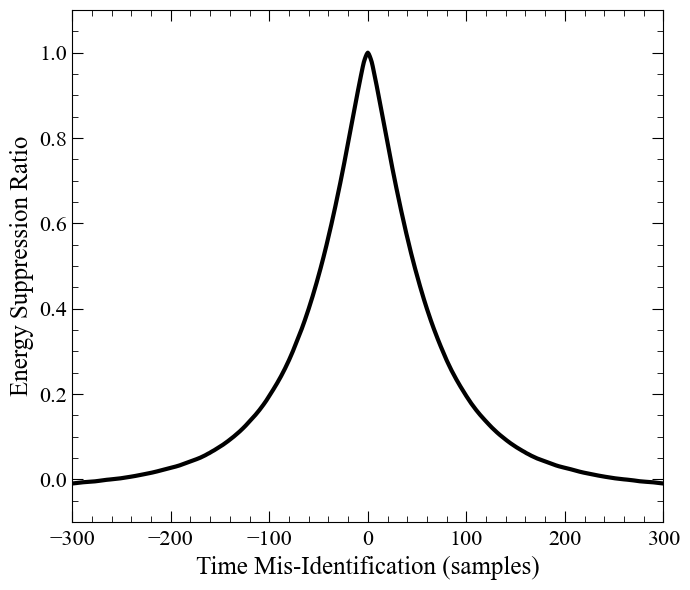

In [ ]:
waveform_test = np.zeros(3 * len(templates_td))
waveform_test[len(templates_td):2*len(templates_td)] = templates_td
oftrigger_1x1.update_trace(waveform_test)
filtered_trace = oftrigger_1x1.get_filtered_trace()[0]
i_max = np.argmax(filtered_trace)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
#ax.plot(delta_t_arr, rho_arr, label=r'$\rho$ ($\Delta$ t)', color='r', lw=3)
ax.plot(delta_t_arr, filtered_trace[i_max - 1000 : i_max + 1001], label='Optimal Filter applied to Template', color='k', linestyle='-', lw=3)
ax.set_xlabel('Time Mis-Identification (samples)')
ax.set_ylabel('Energy Suppression Ratio')
#ax.legend(fontsize=14)
ax.set_xlim([-300, 300])
ax.set_ylim([-0.1, 1.1])
fig.tight_layout()
fig.show()


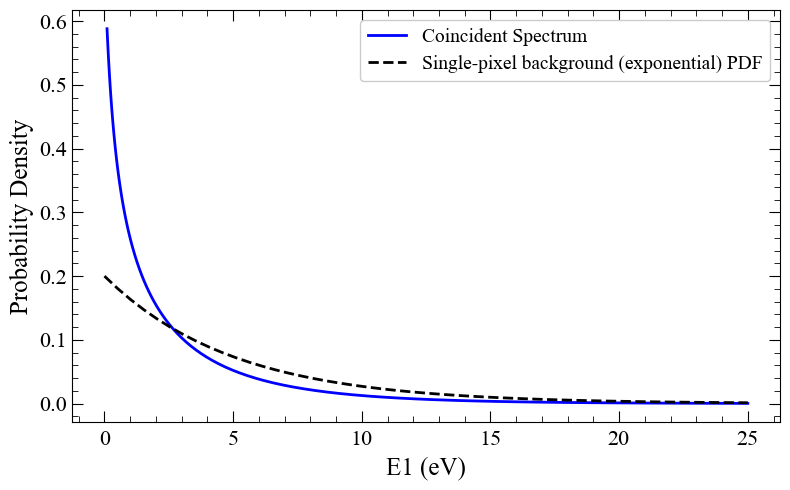

In [ ]:
# Calculate the coincident spectrum of E1, given E0

rate_Hz = 50.

E1_eV_arr = np.geomspace(0.1, 25, 100)
E1_PDF_arr = np.zeros_like(E1_eV_arr)

for i, E1_obs in enumerate(E1_eV_arr):
    for delta_t_samples in range(-200, 200):
        
        delta_t = delta_t_samples / fs
        rho = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t_samples)[0,0]
        pdf_delta_t = rate_Hz * np.exp(-1 * rate_Hz  * abs(delta_t)) / 2
        
        E1_real = E1_obs / max(0.001, rho)
        pdf_E1_real = lambda_E * np.exp(-1 * E1_real * lambda_E)
        
        E1_PDF_arr[i] += pdf_delta_t * pdf_E1_real
    
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

integral = np.trapz(E1_PDF_arr, E1_eV_arr)
ax.plot(E1_eV_arr, E1_PDF_arr / integral, 'b', label='Coincident Spectrum')
ax.plot(np.linspace(0, 25), lambda_E * np.exp(-lambda_E * np.linspace(0, 25)), 'k--', label='Single-pixel background (exponential) PDF', lw=2)

#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Probability Density')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

In [ ]:
# When you decrease the single-pixel rate (rate_Hz), the coincident rate decreases much faster than the single-pixel rate.
# This is because coincidences require two independent random events (one in each pixel) to occur within a short coincidence window.
# 
# The probability of a coincidence is roughly proportional to the product of the rates in each pixel and the coincidence window width:
#     R_coinc ≈ rate_Hz^2 * Δt_window
# 
# In contrast, the single-pixel rate is just:
#     R_single ≈ rate_Hz
# 
# Therefore, the ratio:
#     R_coinc / R_single ≈ rate_Hz * Δt_window
# 
# As you decrease rate_Hz, this ratio decreases linearly with rate_Hz.
# This is why the coincident rate falls off much faster than the single-pixel rate as you lower the rate.

rate_Hz = 100.

E1_eV_arr = np.geomspace(0.01, 30, 150)
E1_dRdE_arr = np.zeros_like(E1_eV_arr)

delta_t_samples_arr = np.arange(-300, 300)
delta_t_s_arr = delta_t_samples_arr / fs

def process_E1_obs(args):
    E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1 = args
    result = 0.0
    
    for j, (delta_t_samples, delta_t_s) in enumerate(zip(delta_t_samples_arr, delta_t_s_arr)):
        rho = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t_samples)[0,0]
        
        pdf_delta_t_Hz = rate_Hz * np.exp(-1 * rate_Hz * abs(delta_t_s)) / 2
        
        E1_real = E1_obs / max(0.001, rho)
        dRdE_bkgd_Hz_per_eV = rate_Hz * lambda_E * np.exp(-1 * E1_real * lambda_E)
        
        result += pdf_delta_t_Hz * dRdE_bkgd_Hz_per_eV * np.diff(delta_t_s_arr)[min(j - 1, 0)]
    
    return E1_obs, result

# Prepare arguments for each E1_obs value
args_list = [(E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1) 
             for E1_obs in E1_eV_arr]

# Create a process pool with max 4 CPUs and map the function
with Pool(processes=6) as pool:
    results = pool.map(process_E1_obs, args_list)

# Sort results by E1_obs and extract values
results.sort(key=lambda x: x[0])
E1_dRdE_arr = np.array([r[1] for r in results])
        
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(E1_eV_arr, rate_Hz * lambda_E * np.exp(-lambda_E * E1_eV_arr), 'k--', label='Single-pixel background (exponential)', lw=2)
ax.plot(E1_eV_arr, E1_dRdE_arr, 'b-', label='Coincident Spectrum')

R_coincident = np.trapz(E1_dRdE_arr, E1_eV_arr)
R_single = np.trapz(rate_Hz * lambda_E * np.exp(-lambda_E * E1_eV_arr), E1_eV_arr)
ax.text(0.05, 0.15, f'R_single = {R_single:.2e} Hz', transform=ax.transAxes, fontsize=14)
ax.text(0.05, 0.07, f'R_coincidence = {R_coincident:.2e} Hz', transform=ax.transAxes, fontsize=14, color='b')

#R_coinc = {R_coincident:.2e} Hz\n
print(f'Coincident Rate: {R_coincident:.2e} Hz, Single-pixel Rate: {R_single:.2f} Hz, Ratio: {R_coincident / R_single:.2e}')

#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Rate [Hz/eV]')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

### With the LEE Spectrum

In [ ]:
from scipy.interpolate import interp1d
def run57_lee_bkgd():
    fin = 'Run57_LEE_templates/combined_spectra_shared57.txt'
    template = np.loadtxt(fin,skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400.)

Run57 LEE Background: 1.08e+01 Hz


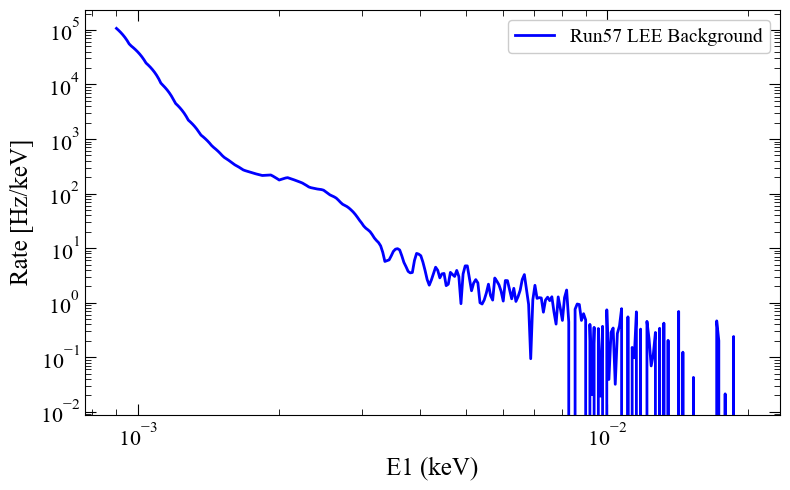

In [ ]:
E1_keV_arr = np.geomspace(0.9, 20, 150) * 1e-3
fun = run57_lee_bkgd()
E1_dRdE_arr = np.array([fun(E) for E in E1_keV_arr])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(E1_keV_arr, E1_dRdE_arr, 'b-', label='Run57 LEE Background', lw=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E1 (keV)')
ax.set_ylabel('Rate [Hz/keV]')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

print(f'Run57 LEE Background: {np.trapz(E1_dRdE_arr, E1_keV_arr):.2e} Hz')

In [ ]:
fun = lambda x: run57_lee_bkgd()(x)
fun = lambda x: np.exp(-x / 0.005) * 1000  # Exponential decay for testing
fun = lambda x: x**-3 * 1e-5 # Falling power law for testing
#fun = lambda x: 10 * (3 - 1) * (1e-3)**(3 - 1) * (x + 1e-3)**(-3)  # Shifted power law with N = 1e-5, b = 3, a = 1e-3 for testing

E1_keV_arr = np.geomspace(0.9, 20, 150) * 1e-3
E1_dRdE_arr = np.zeros_like(E1_keV_arr)
E1_dRdE_single_arr = np.zeros_like(E1_keV_arr)

# Calculate the single-pixel background spectrum
for i, E in enumerate(E1_keV_arr):
    E1_dRdE_single_arr[i] = fun(E)

rate_Hz = np.trapz(E1_dRdE_single_arr, E1_keV_arr)
print(f'Single-pixel Rate: {rate_Hz:.2e} Hz')

delta_t_samples_arr = np.arange(-300, 300)
delta_t_s_arr = delta_t_samples_arr / fs

def process_E1_obs(args):
    E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1 = args
    result = 0.0
    
    for j, (delta_t_samples, delta_t_s) in enumerate(zip(delta_t_samples_arr, delta_t_s_arr)):
        rho = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t_samples)[0,0]
        
        pdf_delta_t_Hz = rate_Hz * np.exp(-1 * rate_Hz * abs(delta_t_s)) / 2
        
        E1_real = E1_obs / max(0.001, rho)
        dRdE_bkgd_Hz_per_eV = fun(E1_real)
        
        result += pdf_delta_t_Hz * dRdE_bkgd_Hz_per_eV * np.diff(delta_t_s_arr)[min(j - 1, 0)]
    
    return E1_obs, result

# Prepare arguments for each E1_obs value
args_list = [(E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1) 
             for E1_obs in E1_keV_arr]

# Create a process pool with max 4 CPUs and map the function
with Pool(processes=6) as pool:
    results = pool.map(process_E1_obs, args_list)

# Sort results by E1_obs and extract values
results.sort(key=lambda x: x[0])
E1_dRdE_arr = np.array([r[1] for r in results])

np.savetxt('Run57_LEE_templates/coincident_2fold.txt',
           np.column_stack((E1_keV_arr, E1_dRdE_arr * 86400)),
           fmt='%.4e', header='E [keV] dRdE [cts/keV/day]')

##################

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

integral = np.trapz(E1_dRdE_single_arr, E1_keV_arr)
ax.plot(E1_keV_arr, E1_dRdE_single_arr / integral, 'k--', label='Single-pixel background (LEE)', lw=2)
integral = np.trapz(E1_dRdE_arr, E1_keV_arr)
ax.plot(E1_keV_arr, E1_dRdE_arr / integral, 'b-', label='Coincident Spectrum')

ax.set_yscale('log')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Probability Density [1/eV]')
fig.tight_layout()
fig.show()


fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(E1_keV_arr, E1_dRdE_single_arr * 86400, 'k--', label='Single-pixel background (LEE)', lw=2)
ax.plot(E1_keV_arr, E1_dRdE_arr * 86400, 'b-', label='Coincident Spectrum')

R_coincident = np.trapz(E1_dRdE_arr, E1_keV_arr)
R_single = np.trapz(E1_dRdE_single_arr, E1_keV_arr)
ax.text(0.03, 0.15, f'R_single = {R_single:.2e} Hz', transform=ax.transAxes, fontsize=14)
ax.text(0.03, 0.07, f'R_coincidence = {R_coincident:.2e} Hz', transform=ax.transAxes, fontsize=14, color='b')

#R_coinc = {R_coincident:.2e} Hz\n
print(f'Coincident Rate: {R_coincident:.2e} Hz, Single-pixel Rate: {R_single:.2f} Hz, Ratio: {R_coincident / R_single:.2e}')

#E_DM_keV, dRdE_DM_DRU = DM_spectrum_GaAs(1e9, 1e-34, rng, mediator='NR', plot=False, verbose=False)
#ax.plot(E_DM_keV, dRdE_DM_DRU * 0.005 * 8, 'r-', label='Dark Matter')

#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E1 (keV)')
ax.set_ylabel('Rate [1/keV/day]')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

# Simulating 2-channel waveforms and using an OF for coincidence (also see simulate*.py files, which are newer)

## Set up the parameters

In [ ]:
# Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')
 
# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
n_channels, m_amplitudes, f_frequencies = templates_td.shape
fs = metadata['sample_rate']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))

# Rescale template so that the energy resolution per channel is 0.18 eV
templates_td *= (0.395 / 0.18)

# Background parameters
rate_Hz = 50  # Event rate in Hz
lambda_E = 1 / 4.0  # Decay constant for energy in 1/eV

# Convert to 2D
template_OF = np.zeros((2, 2, f_frequencies))
template_OF[0, 0, :] = templates_td
template_OF[1, 1, :] = templates_td

csd_OF = np.zeros((2, 2, f_frequencies))
csd_OF[0, 0, :] = csd
csd_OF[1, 1, :] = csd

INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


## Run the simulation

In [ ]:
full_data_length_hours = 6
n_cores = 8

sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds

n_simulations = int(np.floor(full_data_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)
print(f'Running {n_simulations} simulations in parallel with {n_cores} cores')

###############

def simulate_and_collect(sim_number):

    rng = np.random.default_rng(12345 + sim_number * 100)

    # Simulate noise for pixel 0
    simulated_waveform_pix0 = qetpy.gen_noise(csd, fs, n_traces_per_sim, rng=rng)
    simulated_waveform_pix0_td = np.zeros((n_channels, f_frequencies * n_traces_per_sim))
    for trace_i in range(n_traces_per_sim):
        simulated_waveform_pix0_td[:, trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_pix0[trace_i, :]

    # Simulate noise for pixel 1
    simulated_waveform_pix1 = qetpy.gen_noise(csd, fs, n_traces_per_sim, rng=rng)
    simulated_waveform_pix1_td = np.zeros((n_channels, f_frequencies * n_traces_per_sim))
    for trace_i in range(n_traces_per_sim):
        simulated_waveform_pix1_td[:, trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_pix1[trace_i, :]

    # Simulate pulses in the two pixels
    expected_events = int(rate_Hz * sim_trace_length_s * 1.5)  # Overestimate to be safe

    # Simulate arrival times and energies for pixel 0
    arrival_times_pix0 = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
    arrival_times_pix0 = arrival_times_pix0[arrival_times_pix0 < (sim_trace_length - f_frequencies)].astype(int)
    energies_pix0 = rng.exponential(1.0 / lambda_E, len(arrival_times_pix0))
    energies_pix0[energies_pix0 > 30.] = 30.

    # Add pulses to pixel 0 waveform
    for i, arrival_time in enumerate(arrival_times_pix0):
        simulated_waveform_pix0_td[0, arrival_time:arrival_time + f_frequencies] += energies_pix0[i] * templates_td[0,0]

    # Simulate arrival times and energies for pixel 1
    arrival_times_pix1 = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
    arrival_times_pix1 = arrival_times_pix1[arrival_times_pix1 < (sim_trace_length - f_frequencies)].astype(int)
    energies_pix1 = rng.exponential(1.0 / lambda_E, len(arrival_times_pix1))
    energies_pix1[energies_pix1 > 30.] = 30.

    # Add pulses to pixel 1 waveform
    for i, arrival_time in enumerate(arrival_times_pix1):
        simulated_waveform_pix1_td[0, arrival_time:arrival_time + f_frequencies] += energies_pix1[i] * templates_td[0,0]

    # Convert waveform, template, and CSD into OF format
    simulated_waveform_td = np.concatenate([simulated_waveform_pix0_td, simulated_waveform_pix1_td])

    # Process the data
    oftrigger = detprocess.OptimumFilterTrigger('MyTrigger0|MyTrigger1', fs, template_OF, csd_OF, pretrigger_samples=int(f_frequencies/2))

    # Run OF Trigger
    oftrigger.update_trace(simulated_waveform_td)
    dynamic_threshold_function = lambda amp: max(100, 2 * 78 * np.log(amp / 13))
    oftrigger.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)

    # Extract trigger amplitudes and times
    E0_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_amplitude_0']
    E1_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_amplitude_1']
    trigger_times = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_index']
    filtered_trace_0, filtered_trace_1 = oftrigger.get_filtered_trace()
    delta_chi2_trace = oftrigger.get_filtered_delta_chi2()
    n_triggers = len(E0_arr)

    if sim_number % n_cores == 0:
        print(f'Finished simulation {sim_number}. Found {n_triggers} triggers.')

        # Extract triggered waveforms
        pulses = np.zeros((n_triggers, 3, f_frequencies))
        pre = post = int(f_frequencies/2)
        for i, t in enumerate(trigger_times):
            pulses[i,0,:] = filtered_trace_0[(t - pre):(t + post)]
            pulses[i,1,:] = filtered_trace_1[(t - pre):(t + post)]
            pulses[i,2,:] = delta_chi2_trace[(t - pre):(t + post)]

        with h5py.File(f'Test/simulated_waveform_{sim_number:04d}.h5', 'w') as f:
            f.create_dataset('pulses', data=pulses)
            f.create_dataset('trigger_time', data=trigger_times)
            f.create_dataset('E0', data=E0_arr)
            f.create_dataset('E1', data=E1_arr)

        del pulses

    del simulated_waveform_td

    return list(E0_arr), list(E1_arr), [sim_number] * n_triggers, list(trigger_times)

with Pool(n_cores) as pool:
    results = pool.map(simulate_and_collect, range(n_simulations))

E0_full = np.array([e for result in results for e in result[0]])
E1_full = np.array([e for result in results for e in result[1]])
sim_number_full = np.array([e for result in results for e in result[2]])
trigger_time_full = np.array([e for result in results for e in result[3]])

with h5py.File(f'Test/summary.h5', 'w') as f:
    f.create_dataset('simulation_number', data=sim_number_full)
    f.create_dataset('trigger_time', data=trigger_time_full)
    f.create_dataset('E0', data=E0_full)
    f.create_dataset('E1', data=E1_full)

########################################################

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

h = ax.hist2d(E0_full, E1_full,
           bins=(100, 100), norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax, label='Counts')

ax.set_xlabel('Energy in Pixel 0 [eV]')
ax.set_ylabel('Energy in Pixel 1 [eV]')
fig.tight_layout()
fig.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

detected = (E0_full > 0.9) * (E1_full > 0.9)
ax.hist(E0_full[detected], np.linspace(0., 10, 100), density=True, alpha=0.5, label='Pixel 0')
#ax.hist(E1_arr, np.linspace(0., 50, 100), density=True, alpha=0.5, label='Pixel 1')
ax.set_xlabel('Energy in Pixel [eV]')
ax.set_ylabel('Density (1/eV)')
#lambda_E_test = 1 / 5.
#ax.plot(np.linspace(0., 40, 100), lambda_E_test * np.exp(-lambda_E_test * np.linspace(0., 40, 100)), color='k', label=f'Single-Pixel Exponential PDF (tau_E = {1/lambda_E_test} eV)', lw=2)
ax.legend(loc='best', fontsize=14)

fig.tight_layout()
fig.show()


Running 2160 simulations in parallel with 8 cores


Finished simulation 272. Found 757 triggers.
Finished simulation 0. Found 771 triggers.
Finished simulation 408. Found 763 triggers.
Finished simulation 136. Found 771 triggers.


In [ ]:
oftrigger_1x1 = detprocess.OptimumFilterTrigger('MyTrigger', fs, template_OF[0,0], csd_OF[0,0], pretrigger_samples=int(f_frequencies/2))

E1_eV_arr = np.geomspace(0.01, 30, 150)
E1_dRdE_arr = np.zeros_like(E1_eV_arr)

delta_t_samples_arr = np.arange(-300, 300)
delta_t_s_arr = delta_t_samples_arr / fs

def process_E1_obs(args):
    E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1 = args
    result = 0.0
    
    for j, (delta_t_samples, delta_t_s) in enumerate(zip(delta_t_samples_arr, delta_t_s_arr)):
        rho = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t_samples)[0,0]
        
        pdf_delta_t_Hz = rate_Hz * np.exp(-1 * rate_Hz * abs(delta_t_s)) / 2
        
        E1_real = E1_obs / max(0.001, rho)
        dRdE_bkgd_Hz_per_eV = rate_Hz * lambda_E * np.exp(-1 * E1_real * lambda_E)
        
        result += pdf_delta_t_Hz * dRdE_bkgd_Hz_per_eV * np.diff(delta_t_s_arr)[min(j - 1, 0)]
    
    return E1_obs, result

# Prepare arguments for each E1_obs value
args_list = [(E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1) 
             for E1_obs in E1_eV_arr]

# Create a process pool with max 4 CPUs and map the function
with Pool(processes=6) as pool:
    results = pool.map(process_E1_obs, args_list)

# Sort results by E1_obs and extract values
results.sort(key=lambda x: x[0])
E1_dRdE_arr = np.array([r[1] for r in results])

## Plot results

134084 134493 268889 872


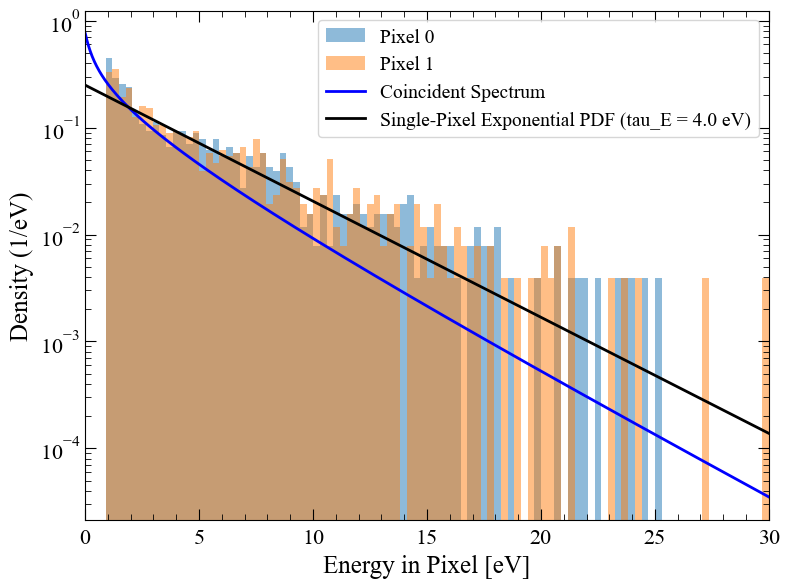

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

detected = (E0_full > 0.9) * (E1_full > 0.9)
print(sum(E0_full > 0.9), sum(E1_full > 0.9), len(detected), sum(detected))

ax.hist(E0_full[detected], np.linspace(0.9, 30, 100), density=True, alpha=0.5, label='Pixel 0')
ax.hist(E1_full[detected], np.linspace(0.9, 30, 100), density=True, alpha=0.5, label='Pixel 1')
ax.plot(E1_eV_arr, E1_dRdE_arr / np.trapz(E1_dRdE_arr, E1_eV_arr), 'b-', label='Coincident Spectrum')
ax.set_xlabel('Energy in Pixel [eV]')
ax.set_ylabel('Density (1/eV)')
ax.plot(np.linspace(0, 30, 100), lambda_E * np.exp(-lambda_E * np.linspace(0, 30, 100)), color='k', label=f'Single-Pixel Exponential PDF (tau_E = {1/lambda_E} eV)', lw=2)
#ax.plot(E1_eV_arr, E1_PDxF_arr / integral, 'b', label='Coincident Spectrum')

ax.set_yscale('log')
ax.legend(loc='best', fontsize=14)
ax.set_xlim([0, 30])

fig.tight_layout()
fig.show()

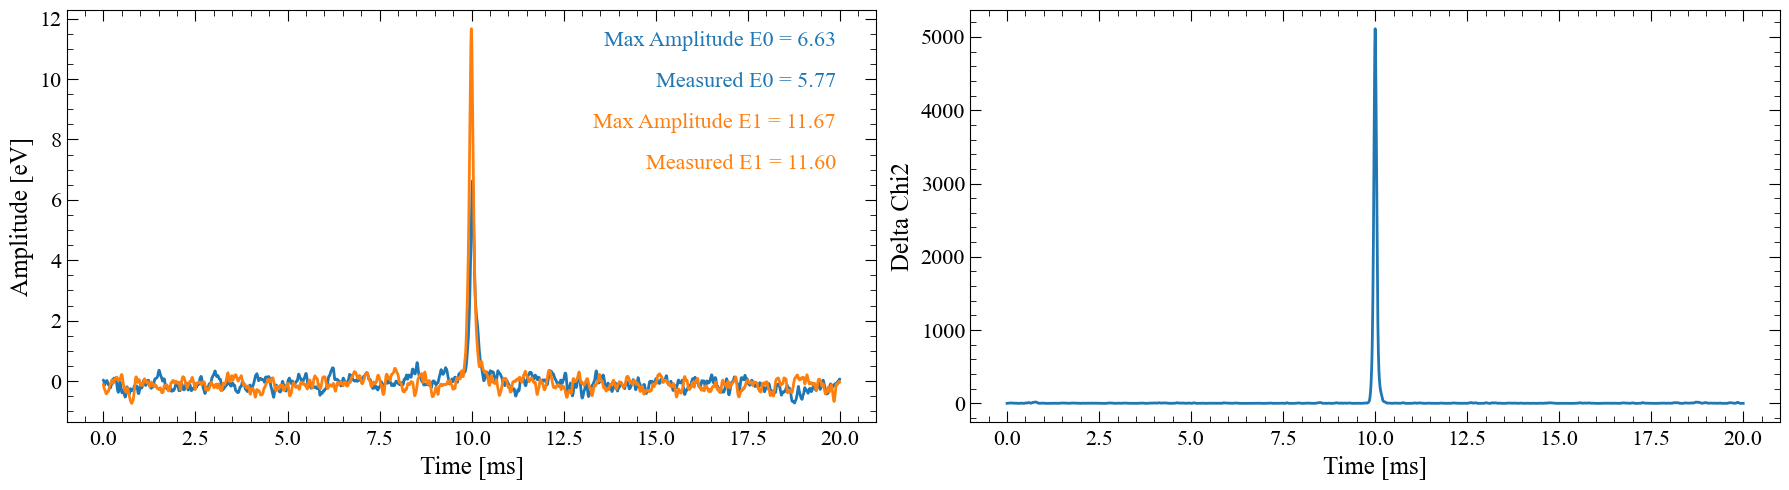

In [ ]:
s = 88

low_energy = detected * ((E0_full < 3) + (E1_full < 3)) * (sim_number_full == s)
high_energy = detected * ((E0_full > 10) + (E1_full > 10)) * (sim_number_full == s)

for idx in np.where(high_energy)[0]:

    with h5py.File(f'Test/simulated_waveform_{s:04d}.h5', 'r') as f:
        
        times_in_file = np.array(f['trigger_time'])
        j = np.where(times_in_file == trigger_time_full[idx])[0][0]
        pulse = np.array(f['pulses'])[j]
        E0 = np.array(f['E0'])[j]
        E1 = np.array(f['E1'])[j]
        trace_len = len(pulse[0])
    
        fig, ax = plt.subplots(1, 2, figsize=(18, 5))

        ax[0].plot(np.arange(len(pulse[0])) / fs * 1e3, pulse[0])
        ax[0].plot(np.arange(len(pulse[1])) / fs * 1e3, pulse[1])
        t_min = int(trace_len / 2 - 1000)
        t_max = int(trace_len / 2 + 1000)
        ax[0].text(0.95, 0.95, f'Max Amplitude E0 = {max(pulse[0][t_min:t_max]):.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C0')
        ax[0].text(0.95, 0.85, f'Measured E0 = {E0:.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C0')
        ax[0].text(0.95, 0.75, f'Max Amplitude E1 = {max(pulse[1][t_min:t_max]):.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C1')
        ax[0].text(0.95, 0.65, f'Measured E1 = {E1:.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C1')
        ax[0].set_xlabel('Time [ms]')
        ax[0].set_ylabel('Amplitude [eV]')

        ax[1].plot(np.arange(len(pulse[2])) / fs * 1e3, pulse[2])
        ax[1].set_xlabel('Time [ms]')
        ax[1].set_ylabel('Delta Chi2')

        fig.tight_layout()
        fig.show()

## Delta Delta Chi2 Development (Hypothesis-Testing between 1-time and 2- or 3-times)

In [ ]:
# Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')
 
# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
n_channels, m_amplitudes, f_frequencies = templates_td.shape
fs = metadata['sample_rate']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))

# Rescale template so that the energy resolution per channel is 0.18 eV
templates_td *= (0.395 / 0.18)

# Background parameters
rate_Hz = 50  # Event rate in Hz
lambda_E = 1 / 4.0  # Decay constant for energy in 1/eV

# Convert to 2D
template_OF = np.zeros((2, 2, f_frequencies))
template_OF[0, 0, :] = templates_td
template_OF[1, 1, :] = templates_td

csd_OF = np.zeros((2, 2, f_frequencies))
csd_OF[0, 0, :] = csd
csd_OF[1, 1, :] = csd

INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
rng = np.random.default_rng()
n_cores = 6
n_sims = 1000

def compute_delta_delta(seed):
    
    rng = np.random.default_rng(seed)
    
    # Simulate noise for pixel 0
    simulated_waveform_pix0 = qetpy.gen_noise(csd_OF[0,0], fs, 3, rng=rng)
    simulated_waveform_pix0_td = np.zeros((n_channels, f_frequencies * 3))
    for trace_i in range(3):
        simulated_waveform_pix0_td[:, trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_pix0[trace_i, :]

    # Simulate noise for pixel 1
    simulated_waveform_pix1 = qetpy.gen_noise(csd_OF[1,1], fs, 3, rng=rng)
    simulated_waveform_pix1_td = np.zeros((n_channels, f_frequencies * 3))
    for trace_i in range(3):
        simulated_waveform_pix1_td[:, trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_pix1[trace_i, :]

    # Define arrival times and energies
    arrival_time_pix0 = 100
    energy_pix0 = 2.5
    arrival_time_pix1 = 100
    energy_pix1 = 5.

    # Simulate energy deposits in both pixels
    real_time_0 = arrival_time_pix0 + f_frequencies
    real_time_1 = arrival_time_pix1 + f_frequencies
    simulated_waveform_pix0_td[0, real_time_0:real_time_0 + f_frequencies] += energy_pix0 * template_OF[0,0]
    simulated_waveform_pix1_td[0, real_time_1:real_time_1 + f_frequencies] += energy_pix1 * template_OF[1,1]

    # Convert waveform, template, and CSD into OF format
    simulated_waveform_td = np.concatenate([simulated_waveform_pix0_td, simulated_waveform_pix1_td])

    dynamic_threshold_function = lambda amp: max(100, 2 * 78 * np.log(amp / 13))

    # Process the data
    oftrigger = detprocess.OptimumFilterTrigger('MyTrigger0|MyTrigger1', fs, template_OF, csd_OF, pretrigger_samples=int(f_frequencies/2))
    oftrigger.update_trace(simulated_waveform_td)
    oftrigger.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    delta_chi2_2x2 = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_delta_chi2'][0]

    oftrigger = detprocess.OptimumFilterTrigger('MyTrigger0', fs, template_OF[0,0], csd_OF[0,0], pretrigger_samples=int(f_frequencies/2))
    oftrigger.update_trace(simulated_waveform_td[0])
    oftrigger.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    delta_chi2_1x1_a = oftrigger.get_trigger_data()['MyTrigger0']['trigger_delta_chi2'][0]

    oftrigger = detprocess.OptimumFilterTrigger('MyTrigger1', fs, template_OF[1,1], csd_OF[1,1], pretrigger_samples=int(f_frequencies/2))
    oftrigger.update_trace(simulated_waveform_td[1])
    oftrigger.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    delta_chi2_1x1_b = oftrigger.get_trigger_data()['MyTrigger1']['trigger_delta_chi2'][0]

    return (delta_chi2_1x1_a + delta_chi2_1x1_b) - delta_chi2_2x2


with Pool(processes=n_cores) as pool:
    t = int(time.time())
    delta_delta = pool.starmap(compute_delta_delta, [(t + k*100, ) for k in range(n_sims)])
    delta_delta = np.array(delta_delta)


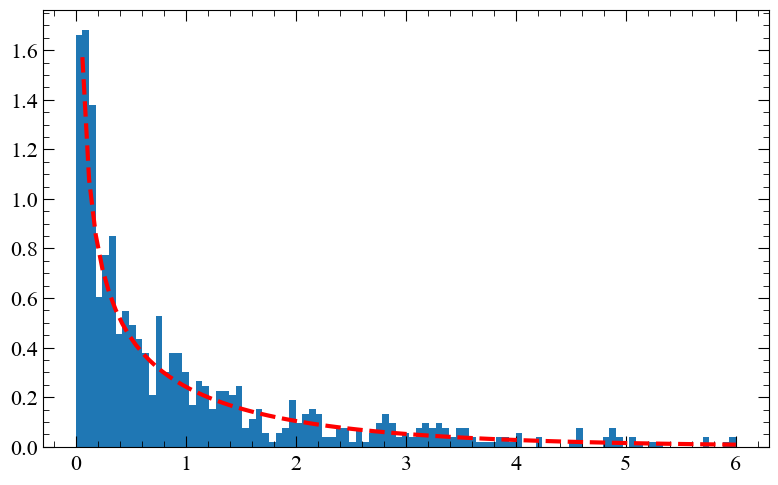

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.hist(delta_delta[delta_delta > 0], np.linspace(0, 6, 100), density=True)
x = np.linspace(0, 6, 100)
y = stats.chi2.pdf(x, 1)
ax.plot(x, y, 'r--', lw=3, label=r'$\chi^2$(k=1)')
ax.set_xlabel(r'$\Delta \Delta \chi^2$')
ax.set_ylabel('Density')

fig.tight_layout()
fig.show()


## Delta Delta Chi2 Cut Implementation

In [28]:
# Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')
 
# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
n_channels, m_amplitudes, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))

# Rescale template so that the energy resolution per channel is 0.18 eV
templates_td *= (0.395 / 0.18)

# Background parameters
rate_Hz = 75  # Event rate in Hz

# Convert to 2D
template_OF = np.zeros((2, 2, f_frequencies))
template_OF[0, 0, :] = templates_td
template_OF[1, 1, :] = templates_td

csd_OF = np.zeros((2, 2, f_frequencies))
csd_OF[0, 0, :] = csd
csd_OF[1, 1, :] = csd


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [29]:
def get_closest_time(trigger_times, t):
    """
    Find the closest time in trigger_times to t and its index.
    """
    # Find the index in trigger_times closest to t (trigger_times is sorted)
    idx = np.searchsorted(trigger_times, t)
    if idx == 0:
        closest_idx = 0
    elif idx == len(trigger_times):
        closest_idx = len(trigger_times) - 1
    else:
        if abs(trigger_times[idx] - t) < abs(trigger_times[idx - 1] - t):
            closest_idx = idx
        else:
            closest_idx = idx - 1

    return trigger_times[closest_idx], closest_idx

def run57_lee_bkgd():
    fin = 'Run57_LEE_templates/combined_spectra_shared57.txt'
    template = np.loadtxt(fin,skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400.)


In [ ]:
full_data_length_hours = 12
n_cores = 12

sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds

n_simulations = int(np.floor(full_data_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)
print(f'Running {n_simulations} simulations in parallel with {n_cores} cores')

E_cutoff = 0.9e-3
E_arr = np.geomspace(E_cutoff, 30, 250)
dRdE_arr = run57_lee_bkgd()(E_arr)
R_LEE = np.trapz(dRdE_arr, E_arr)
print(f'Run57 LEE Background: {R_LEE:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')

###############

def simulate_and_collect(sim_number):

    rng = np.random.default_rng(int(time.time()) + sim_number * 100)

    # Simulate noise in the two pixels
    simulated_waveform_joint = qetpy.gen_noise(csd_OF, fs, n_traces_per_sim, rng=rng)
    simulated_waveform_pix0_td = np.zeros(f_frequencies * n_traces_per_sim)
    simulated_waveform_pix1_td = np.zeros(f_frequencies * n_traces_per_sim)
    for trace_i in range(n_traces_per_sim):
        simulated_waveform_pix0_td[trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_joint[trace_i, 0, :]
        simulated_waveform_pix1_td[trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_joint[trace_i, 1, :]

    # Simulate pulses in the two pixels
    expected_events = int(rate_Hz * sim_trace_length_s * 1.5)  # Overestimate to be safe
    
    SE = darklim.sensitivity.SensEst(1, 1/86400 * expected_events / R_LEE, tm='GaAs', eff=1., gain=1., seed=int(time.time()) + sim_number * 100)
    SE.reset_sim()
    SE.add_run57_lee_bkgd(fin='Run57_LEE_templates/combined_spectra_shared57.txt')

    # Simulate arrival times and energies for pixel 0
    arrival_times_pix0 = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
    arrival_times_pix0 = arrival_times_pix0[arrival_times_pix0 < (sim_trace_length - f_frequencies)].astype(int)
    energies_pix0 = SE.generate_background(100e-3, e_low=E_cutoff) * 1000 # Convert to eV

    # Add pulses to pixel 0 waveform
    for i, arrival_time in enumerate(arrival_times_pix0):
        simulated_waveform_pix0_td[arrival_time:arrival_time + f_frequencies] += energies_pix0[i] * templates_td[0,0]

    # Simulate arrival times and energies for pixel 1
    arrival_times_pix1 = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
    arrival_times_pix1 = arrival_times_pix1[arrival_times_pix1 < (sim_trace_length - f_frequencies)].astype(int)
    energies_pix1 = SE.generate_background(100e-3, e_low=E_cutoff) * 1000 # Convert to eV

    # Add pulses to pixel 1 waveform
    for i, arrival_time in enumerate(arrival_times_pix1):
        simulated_waveform_pix1_td[arrival_time:arrival_time + f_frequencies] += energies_pix1[i] * templates_td[0,0]
       
    # Convert waveform, template, and CSD into OF format
    simulated_waveform_td = np.concatenate([[simulated_waveform_pix0_td], [simulated_waveform_pix1_td]])

    # Process the data with a 2x2 trigger
    oftrigger = detprocess.OptimumFilterTrigger('MyTrigger0|MyTrigger1', fs, template_OF, csd_OF, pretrigger_samples=pretrig)
    oftrigger.update_trace(simulated_waveform_td)
    dynamic_threshold_function = lambda amp: max(100, 2 * 78 * np.log(amp / 13))
    oftrigger.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)

    # Extract trigger amplitudes and times from the 2x2 trigger
    E0_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_amplitude_0']
    E1_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_amplitude_1']
    trigger_times = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_index']
    trigger_delta_chi2 = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_delta_chi2']
    
    filtered_trace_0, filtered_trace_1 = oftrigger.get_filtered_trace()
    delta_chi2_trace = oftrigger.get_filtered_delta_chi2()
    n_triggers = len(E0_arr)

    # Reprocess the data with a 1x1 trigger on pixel 0 and 1x1 trigger on pixel 1
    oftrigger_a = detprocess.OptimumFilterTrigger('MyTrigger0', fs, template_OF[0,0], csd_OF[0,0], pretrigger_samples=pretrig)
    oftrigger_a.update_trace(simulated_waveform_td[0])
    oftrigger_a.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    trigger_times_a = oftrigger_a.get_trigger_data()['MyTrigger0']['trigger_index']
    trigger_delta_chi2_a = oftrigger_a.get_trigger_data()['MyTrigger0']['trigger_delta_chi2']
    E0_arr_a = oftrigger_a.get_trigger_data()['MyTrigger0']['trigger_amplitude_0']

    oftrigger_b = detprocess.OptimumFilterTrigger('MyTrigger1', fs, template_OF[1,1], csd_OF[1,1], pretrigger_samples=pretrig)
    oftrigger_b.update_trace(simulated_waveform_td[1])
    oftrigger_b.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    trigger_times_b = oftrigger_b.get_trigger_data()['MyTrigger1']['trigger_index']
    trigger_delta_chi2_b = oftrigger_b.get_trigger_data()['MyTrigger1']['trigger_delta_chi2']

    # For each trigger, compare chi2 values from the three triggers:
    if sim_number % n_cores == 0:
        print(f'In simulation {sim_number}, starting the loop over {n_triggers} times')
    delta_delta = np.zeros(n_triggers)
    delta_chi2_1x1_a = np.zeros(n_triggers)
    delta_chi2_1x1_b = np.zeros(n_triggers)
    for i, trigger_time in enumerate(trigger_times):    

        # Chi2 from the 2x2 trigger
        delta_chi2_2x2 = trigger_delta_chi2[i]
        
        # Find the pulse in pixel 0 that is closest to the trigger time
        time_a, idx_a = get_closest_time(trigger_times_a, trigger_time)
        dchi2_1x1_a = trigger_delta_chi2_a[idx_a]
        
        # Find the pulse in pixel 1 that is closest to the trigger time
        time_b, idx_b = get_closest_time(trigger_times_b, trigger_time)
        dchi2_1x1_b = trigger_delta_chi2_b[idx_b]
        
        delta_delta[i] = (dchi2_1x1_a + dchi2_1x1_b) - delta_chi2_2x2
        delta_chi2_1x1_a[i] = dchi2_1x1_a
        delta_chi2_1x1_b[i] = dchi2_1x1_b

    detected = (np.array(E0_arr) > 0.9) * (np.array(E1_arr) > 0.9)
    waveforms_detected = []
    delta_chi2_detected = []
    
    for i in np.where(detected)[0]:
        t = trigger_times[i]
        
        w0 = np.copy(filtered_trace_0[t - pretrig:t + pretrig])
        w1 = np.copy(filtered_trace_1[t - pretrig:t + pretrig])
        w = np.array([w0, w1])
        waveforms_detected.append(w)
        
        delta_chi2_detected.append((delta_chi2_trace[t - pretrig:t + pretrig], trigger_delta_chi2[i], delta_chi2_1x1_a[i], delta_chi2_1x1_b[i]))

    del simulated_waveform_td

    return list(E0_arr), list(E1_arr), [sim_number] * n_triggers, list(trigger_times), delta_delta, detected, waveforms_detected, delta_chi2_detected, list(E0_arr_a)

# results = []
# for batch_start in range(0, n_simulations, n_cores):
#     batch_indices = list(range(batch_start, min(batch_start + n_cores, n_simulations)))
#     with Pool(n_cores) as pool:
#         batch_results = pool.map(simulate_and_collect, batch_indices)
#     results.extend(batch_results)

# E0_full = np.array([e for result in results for e in result[0]])
# E1_full = np.array([e for result in results for e in result[1]])
# sim_number_full = np.array([e for result in results for e in result[2]])
# trigger_time_full = np.array([e for result in results for e in result[3]])
# delta_delta_full = np.array([e for result in results for e in result[4]])
# detected_full = np.array([e for result in results for e in result[5]])
# E0_a_full = np.array([e for result in results for e in result[8]])

E0_full = []
E1_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

for run_id in range(2):
    with open(f'my_simulation_2fold_{run_id}.pkl', 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        sim_number_full += [e for result in results for e in result[2]]
        trigger_time_full += [e for result in results for e in result[3]]
        delta_delta_full += [e for result in results for e in result[4]]
        detected_full += [e for result in results for e in result[5]]

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)

Running 4320 simulations in parallel with 12 cores
Run57 LEE Background: 1.09e+01 Hz per pixel above 0.90 eV


### Note (Aug 16, 2025): unfortunately the below plot is certainly wrong, but perhaps if you re-run it, the results will be correct.
### The text should be: green = black - (blue + orange)

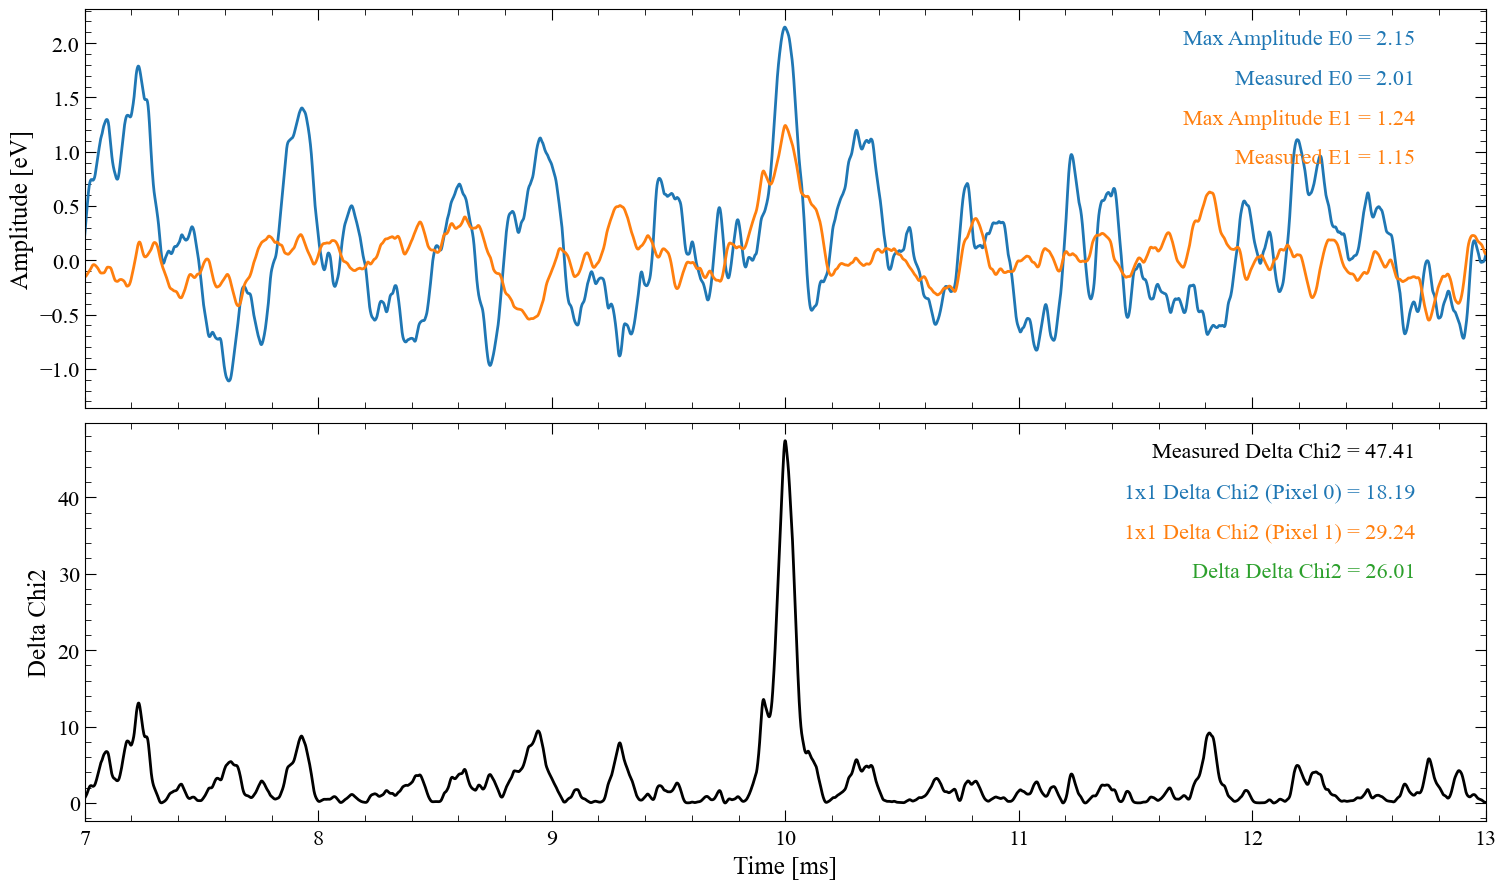

In [31]:
n_plots = 0
max_plots = 0

for i in range(sum(detected_full)):

    j = np.where(detected_full)[0][i]
    
    if delta_delta_full[j] < 25:# or delta_delta_full[j] > 20:
        continue
    
    sim_number = sim_number_full[j]
    n_detections = len(results[sim_number][6])
    if n_detections > 1:
        print('Complicated event with multiple detections')
        continue

    filtered_trace_0, filtered_trace_1 = results[sim_number][6][0]
    delta_chi2_trace, delta_chi2_2x2, delta_chi2_a, delta_chi2_b = results[sim_number][7][0]
    
    fig, ax = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

    ax[0].plot(np.arange(len(filtered_trace_0)) / fs * 1e3, filtered_trace_0)
    ax[0].plot(np.arange(len(filtered_trace_1)) / fs * 1e3, filtered_trace_1)
    ax[0].text(0.95, 0.95, f'Max Amplitude E0 = {max(filtered_trace_0):.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C0')
    ax[0].text(0.95, 0.85, f'Measured E0 = {E0_full[j]:.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C0')
    ax[0].text(0.95, 0.75, f'Max Amplitude E1 = {max(filtered_trace_1):.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C1')
    ax[0].text(0.95, 0.65, f'Measured E1 = {E1_full[j]:.2f}', transform=ax[0].transAxes, ha='right', va='top', fontsize=16, color='C1')
    ax[0].set_ylabel('Amplitude [eV]')
    ax[0].set_xlim([7, 13])
    
    ax[1].plot(np.arange(len(delta_chi2_trace)) / fs * 1e3, delta_chi2_trace, 'k')
    ax[1].text(0.95, 0.95, f'Measured Delta Chi2 = {delta_chi2_2x2:.2f}', transform=ax[1].transAxes, ha='right', va='top', fontsize=16, color='k')
    ax[1].text(0.95, 0.85, f'1x1 Delta Chi2 (Pixel 0) = {delta_chi2_a:.2f}', transform=ax[1].transAxes, ha='right', va='top', fontsize=16, color='C0')
    ax[1].text(0.95, 0.75, f'1x1 Delta Chi2 (Pixel 1) = {delta_chi2_b:.2f}', transform=ax[1].transAxes, ha='right', va='top', fontsize=16, color='C1')
    ax[1].text(0.95, 0.65, f'Delta Delta Chi2 = {delta_delta_full[j]:.2f}', transform=ax[1].transAxes, ha='right', va='top', fontsize=16, color='C2')
    ax[1].set_ylabel('Delta Chi2')
    
    ax[1].set_xlabel('Time [ms]')
    
    fig.tight_layout()
    fig.show()
    
    n_plots += 1
    if n_plots >= max_plots:
        break

4184927 1462


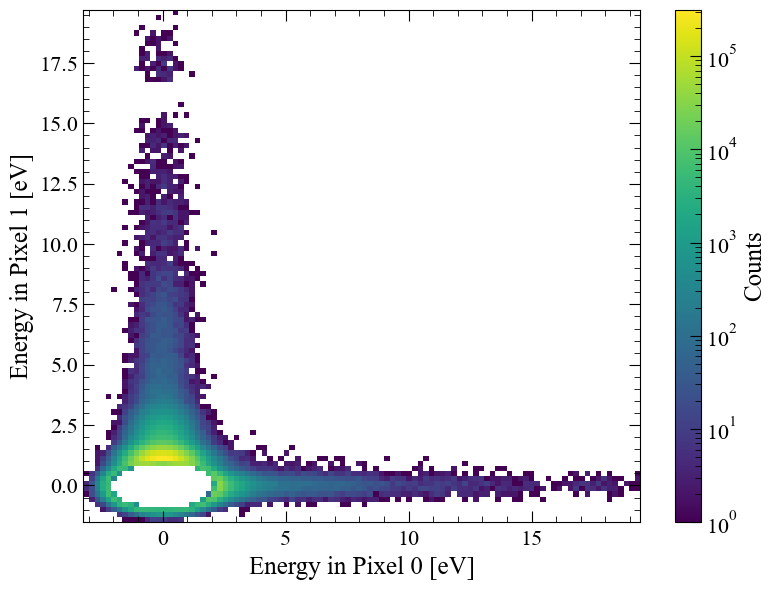

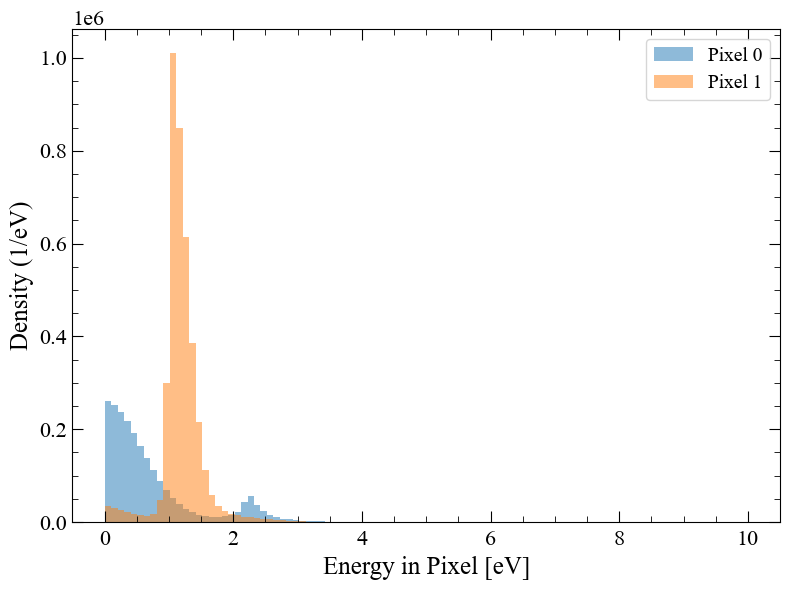

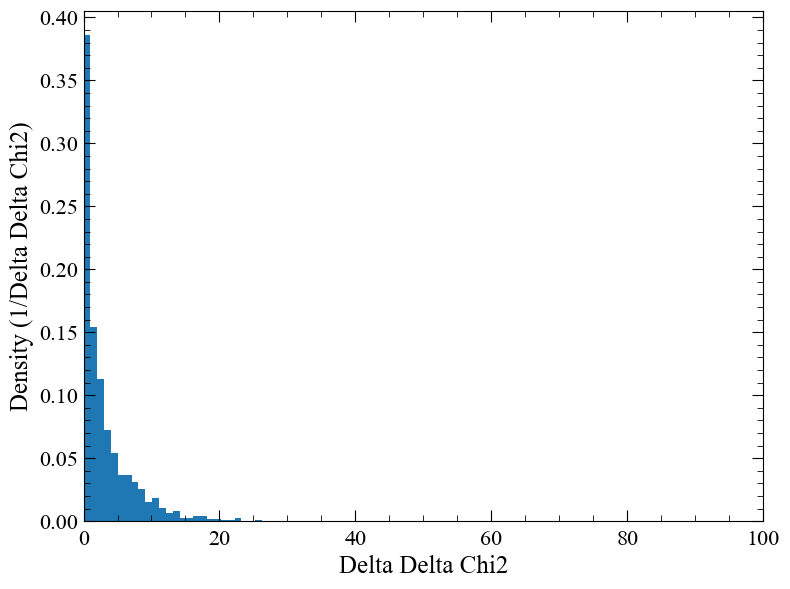

In [32]:
########################################################

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

h = ax.hist2d(E0_full, E1_full,
           bins=(100, 100), norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax, label='Counts')

ax.set_xlabel('Energy in Pixel 0 [eV]')
ax.set_ylabel('Energy in Pixel 1 [eV]')
fig.tight_layout()
fig.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

detected = (E0_full > 2.0) * (E1_full > 0.912)
print(len(detected), sum(detected))
# detected = detected * (delta_delta_full < 25)
# print(len(detected), sum(detected))
# detected = detected * (delta_delta_full < 16)
# print(len(detected), sum(detected))

ax.hist(E0_full, np.linspace(0., 10, 100), density=False, alpha=0.5, label='Pixel 0')
ax.hist(E1_full, np.linspace(0., 10, 100), density=False, alpha=0.5, label='Pixel 1')
ax.set_xlabel('Energy in Pixel [eV]')
ax.set_ylabel('Density (1/eV)')
#lambda_E_test = 1 / 5.
#ax.plot(np.linspace(0., 40, 100), lambda_E_test * np.exp(-lambda_E_test * np.linspace(0., 40, 100)), color='k', label=f'Single-Pixel Exponential PDF (tau_E = {1/lambda_E_test} eV)', lw=2)
ax.legend(loc='best', fontsize=14)

fig.tight_layout()
fig.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(delta_delta_full[detected], np.linspace(0, 100, 100), density=True)
ax.set_xlabel('Delta Delta Chi2')
ax.set_ylabel('Density (1/Delta Delta Chi2)')
ax.set_xlim([0, 100])
fig.tight_layout()
fig.show()

36378.19771142333 539637.1911500238 212.81983242276257 195.47355841022235
4184927 1343


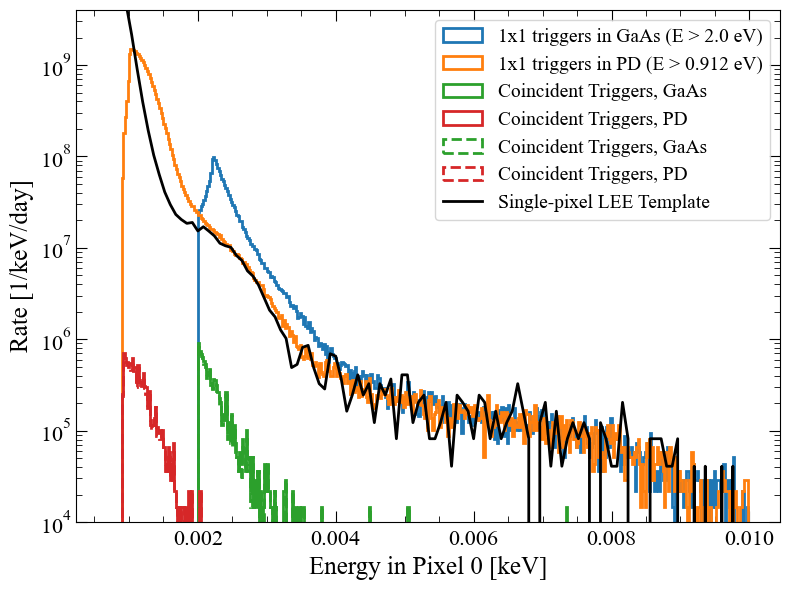

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

n_triggers_per_pixel = rate_Hz * 3600 * full_data_length_hours * 2
duration_s = n_triggers_per_pixel / R_LEE
duration_days = duration_s / 86400

keV_bins = np.arange(0.7, 10, 0.02) * 1e-3
single_pixel = E0_full > 2.
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label='1x1 triggers in GaAs (E > 2.0 eV)')
hist_E, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E * np.diff(bin_edges))

single_pixel = E1_full > 0.912
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label='1x1 triggers in PD (E > 0.912 eV)')
hist_E, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD = sum(hist_E * np.diff(bin_edges))

detected = (E0_full > 2.) * (E1_full > 0.912)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C2', lw=2,
        label='Coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='Coincident Triggers, PD')

hist_E, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident = sum(hist_E * np.diff(bin_edges))

detected = (E0_full > 2.) * (E1_full > 0.912) * (delta_delta_full < 9)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C2', lw=2, ls='--',
        label='Coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2, ls='--',
        label='Coincident Triggers, PD')

hist_E, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_delta = sum(hist_E * np.diff(bin_edges))

E_arr, dRdE_arr, _ = np.loadtxt('Run57_LEE_templates/combined_spectra_shared57.txt', unpack=True)
cut = (E_arr > 0.9e-3) * (E_arr < 10e-3)
E_arr = E_arr[cut]
dRdE_arr = dRdE_arr[cut]
ax.plot(E_arr, dRdE_arr, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_ylim([1e4, 4e9])

# ax.text(0.005, 5e7, f'R = {R_all:.3e} per day', ha='left', va='top', fontsize=16, color='C0')
# ax.text(0.005, 2e7, f'R = {R_2fold:.3e} per day', ha='left', va='top', fontsize=16, color='C1')
# ax.text(0.005, 8e6, f'R = {R_2fold_dchi2:.3e} per day', ha='left', va='top', fontsize=16, color='C2')

ax.set_xlabel('Energy in Pixel 0 [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.legend(loc='best', fontsize=14)

fig.tight_layout()
fig.show()

print(R_single_GaAs, R_single_PD, R_coincident, R_coincident_delta)

print(len(detected), sum(detected))

# Simulating 3-channel data

In [2]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))

### Background parameters
rate_Hz = 100  # Event rate in Hz (for the simulation--this should be as high as possible without inducing pileup)

### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.282
PD_energy_resolution = 0.183
n_sigma = 4.0  # Number of sigma for the trigger

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [3]:
def get_closest_time(trigger_times, t):
    """
    Find the closest time in trigger_times to t and its index.
    """
    # Find the index in trigger_times closest to t (trigger_times is sorted)
    idx = np.searchsorted(trigger_times, t)
    if idx == 0:
        closest_idx = 0
    elif idx == len(trigger_times):
        closest_idx = len(trigger_times) - 1
    else:
        if abs(trigger_times[idx] - t) < abs(trigger_times[idx - 1] - t):
            closest_idx = idx
        else:
            closest_idx = idx - 1

    return trigger_times[closest_idx], closest_idx

def run57_lee_bkgd():
    fin = 'Run57_LEE_templates/combined_spectra_shared57.txt'
    template = np.loadtxt(fin,skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400.)


In [4]:
### Set up the simulation parameters
full_data_length_hours = 6
n_cores = 24

sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds

n_simulations = int(np.floor(full_data_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)
print(f'Running {n_simulations} simulations in parallel with {n_cores} cores')

E_cutoff = 0.72e-3
E_arr = np.geomspace(E_cutoff, 20, 250)
dRdE_arr = run57_lee_bkgd()(E_arr)
R_LEE = np.trapz(dRdE_arr, E_arr)
print(f'LEE Background: {R_LEE:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')

if R_LEE > rate_Hz:
    rate_Hz = R_LEE

###############

def simulate_and_collect(sim_number):

    rng = np.random.default_rng(23456 + sim_number * 100)

    # Simulate pulses in the two pixels
    expected_events = int(rate_Hz * sim_trace_length_s * 1.5)  # Overestimate to be safe
    
    SE = darklim.sensitivity.SensEst(1, 1/86400 * expected_events / R_LEE, tm='GaAs', eff=1., gain=1., seed=98765 + sim_number * 100)
    SE.reset_sim()
    SE.add_run57_lee_bkgd(fin='Run57_LEE_templates/combined_spectra_shared57.txt')

    # Simulate noise in the two pixels
    simulated_waveform_joint = qetpy.gen_noise(csd_OF, fs, n_traces_per_sim, rng=rng)
    simulated_waveform_pix0_td = np.zeros(f_frequencies * n_traces_per_sim)
    simulated_waveform_pix1_td = np.zeros(f_frequencies * n_traces_per_sim)
    simulated_waveform_pix2_td = np.zeros(f_frequencies * n_traces_per_sim)
    for trace_i in range(n_traces_per_sim):
        simulated_waveform_pix0_td[trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_joint[trace_i, 0, :]
        simulated_waveform_pix1_td[trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_joint[trace_i, 1, :]
        simulated_waveform_pix2_td[trace_i * f_frequencies:(trace_i + 1) * f_frequencies] = simulated_waveform_joint[trace_i, 2, :]

    # Simulate arrival times and energies for pixel 0
    arrival_times_pix0 = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
    arrival_times_pix0 = arrival_times_pix0[arrival_times_pix0 < (sim_trace_length - f_frequencies)].astype(int)
    energies_pix0 = SE.generate_background(100e-3, e_low=0.9e-3) * 1000 # Convert to eV
    energies_pix0[energies_pix0 > 30.] = 30.

    # Add pulses to pixel 0 waveform
    for i, arrival_time in enumerate(arrival_times_pix0):
        simulated_waveform_pix0_td[0, arrival_time:arrival_time + f_frequencies] += energies_pix0[i] * templates_td[0,0]

    # Simulate arrival times and energies for pixel 1
    arrival_times_pix1 = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
    arrival_times_pix1 = arrival_times_pix1[arrival_times_pix1 < (sim_trace_length - f_frequencies)].astype(int)
    energies_pix1 = SE.generate_background(100e-3, e_low=0.9e-3) * 1000 # Convert to eV
    energies_pix1[energies_pix1 > 30.] = 30.

    # Add pulses to pixel 1 waveform
    for i, arrival_time in enumerate(arrival_times_pix1):
        simulated_waveform_pix1_td[0, arrival_time:arrival_time + f_frequencies] += energies_pix1[i] * templates_td[0,0]
        
    # Simulate arrival times and energies for pixel 2
    arrival_times_pix2 = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
    arrival_times_pix2 = arrival_times_pix2[arrival_times_pix2 < (sim_trace_length - f_frequencies)].astype(int)
    energies_pix2 = SE.generate_background(100e-3, e_low=0.9e-3) * 1000 # Convert to eV
    energies_pix2[energies_pix2 > 30.] = 30.
    
    # Add pulses to pixel 2 waveform
    for i, arrival_time in enumerate(arrival_times_pix2):
        simulated_waveform_pix2_td[0, arrival_time:arrival_time + f_frequencies] += energies_pix2[i] * templates_td[0,0]

    # Convert waveform, template, and CSD into OF format
    simulated_waveform_td = np.concatenate([simulated_waveform_pix0_td, simulated_waveform_pix1_td, simulated_waveform_pix2_td])

    # Process the data with a 3x3 trigger
    oftrigger = detprocess.OptimumFilterTrigger('MyTrigger0|MyTrigger1|MyTrigger2', fs, template_OF, csd_OF, pretrigger_samples=pretrig)
    oftrigger.update_trace(simulated_waveform_td)
    dynamic_threshold_function = lambda amp: max(100, 2 * 78 * np.log(amp / 13))
    oftrigger.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)

    # Extract trigger amplitudes and times from the 3x3 trigger
    E0_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1|MyTrigger2']['trigger_amplitude_0']
    E1_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1|MyTrigger2']['trigger_amplitude_1']
    E2_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1|MyTrigger2']['trigger_amplitude_2']
    trigger_times = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1|MyTrigger2']['trigger_index']
    trigger_delta_chi2 = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1|MyTrigger2']['trigger_delta_chi2']
    
    filtered_trace_0, filtered_trace_1, filtered_trace_2 = oftrigger.get_filtered_trace()
    delta_chi2_trace = oftrigger.get_filtered_delta_chi2()
    n_triggers = len(E0_arr)

    # Reprocess the data with a 1x1 trigger on each pixel
    oftrigger_a = detprocess.OptimumFilterTrigger('MyTrigger0', fs, template_OF[0,0], csd_OF[0,0], pretrigger_samples=pretrig)
    oftrigger_a.update_trace(simulated_waveform_td[0])
    oftrigger_a.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    trigger_times_a = oftrigger_a.get_trigger_data()['MyTrigger0']['trigger_index']
    trigger_delta_chi2_a = oftrigger_a.get_trigger_data()['MyTrigger0']['trigger_delta_chi2']

    oftrigger_b = detprocess.OptimumFilterTrigger('MyTrigger1', fs, template_OF[1,1], csd_OF[1,1], pretrigger_samples=pretrig)
    oftrigger_b.update_trace(simulated_waveform_td[1])
    oftrigger_b.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    trigger_times_b = oftrigger_b.get_trigger_data()['MyTrigger1']['trigger_index']
    trigger_delta_chi2_b = oftrigger_b.get_trigger_data()['MyTrigger1']['trigger_delta_chi2']
    
    oftrigger_c = detprocess.OptimumFilterTrigger('MyTrigger2', fs, template_OF[2,2], csd_OF[2,2], pretrigger_samples=pretrig)
    oftrigger_c.update_trace(simulated_waveform_td[2])
    oftrigger_c.find_triggers(5, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
    trigger_times_c = oftrigger_c.get_trigger_data()['MyTrigger2']['trigger_index']
    trigger_delta_chi2_c = oftrigger_c.get_trigger_data()['MyTrigger2']['trigger_delta_chi2']

    # For each trigger, compare chi2 values from the three triggers:
    if sim_number % n_cores == 0:
        print(f'In simulation {sim_number}, starting the loop over {n_triggers} times')
    
    delta_delta = np.zeros(n_triggers)
    delta_chi2_1x1_a = np.zeros(n_triggers)
    delta_chi2_1x1_b = np.zeros(n_triggers)
    delta_chi2_1x1_c = np.zeros(n_triggers)
    
    for i, trigger_time in enumerate(trigger_times):    

        # Chi2 from the 3x3 trigger
        delta_chi2_3x3 = trigger_delta_chi2[i]
        
        # Find the pulse in pixel 0 that is closest to the trigger time
        time_a, idx_a = get_closest_time(trigger_times_a, trigger_time)
        dchi2_1x1_a = trigger_delta_chi2_a[idx_a]
        
        # Find the pulse in pixel 1 that is closest to the trigger time
        time_b, idx_b = get_closest_time(trigger_times_b, trigger_time)
        dchi2_1x1_b = trigger_delta_chi2_b[idx_b]
        
        # Find the pulse in pixel 2 that is closest to the trigger time
        time_c, idx_c = get_closest_time(trigger_times_c, trigger_time)
        dchi2_1x1_c = trigger_delta_chi2_c[idx_c]
        
        # Compute the delta delta chi2
        delta_delta[i] = (dchi2_1x1_a + dchi2_1x1_b + dchi2_1x1_c) - delta_chi2_3x3
        delta_chi2_1x1_a[i] = dchi2_1x1_a
        delta_chi2_1x1_b[i] = dchi2_1x1_b
        delta_chi2_1x1_c[i] = dchi2_1x1_c

    detected = (np.array(E0_arr) > 0.9) * (np.array(E1_arr) > 0.9) * (np.array(E2_arr) > 0.9)
    waveforms_detected = []
    delta_chi2_detected = []
    
    for i in np.where(detected)[0]:
        t = trigger_times[i]
        
        w0 = np.copy(filtered_trace_0[t - pretrig:t + pretrig])
        w1 = np.copy(filtered_trace_1[t - pretrig:t + pretrig])
        w2 = np.copy(filtered_trace_2[t - pretrig:t + pretrig])
        w = np.array([w0, w1, w2])
        waveforms_detected.append(w)
        
        delta_chi2_detected.append((delta_chi2_trace[t - pretrig:t + pretrig], trigger_delta_chi2[i], delta_chi2_1x1_a[i], delta_chi2_1x1_b[i], delta_chi2_1x1_c[i]))

    del simulated_waveform_td

    return list(E0_arr), list(E1_arr), list(E2_arr), [sim_number] * n_triggers, list(trigger_times), delta_delta, detected, waveforms_detected, delta_chi2_detected

# with Pool(n_cores) as pool:
#     results = pool.map(simulate_and_collect, range(n_simulations))

# results = []
# for batch_start in range(0, n_simulations, n_cores):
#     batch_indices = list(range(batch_start, min(batch_start + n_cores, n_simulations)))
#     with Pool(n_cores) as pool:
#         batch_results = pool.map(simulate_and_collect, batch_indices)
#     results.extend(batch_results)

# with open('my_simulation.pkl', 'rb') as f:
#     results = pickle.load(f)

# E0_full = np.array([e for result in results for e in result[0]])
# E1_full = np.array([e for result in results for e in result[1]])
# E2_full = np.array([e for result in results for e in result[2]])
# sim_number_full = np.array([e for result in results for e in result[3]])
# trigger_time_full = np.array([e for result in results for e in result[4]])
# delta_delta_full = np.array([e for result in results for e in result[5]])
# detected_full = np.array([e for result in results for e in result[6]])

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

for run_id in range(50):
    fns = glob.glob(f'my_simulation_3fold_{run_id:02d}*.pkl')
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        del results
    print(run_id)

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


Running 2160 simulations in parallel with 24 cores
LEE Background: 7.23e+01 Hz per pixel above 0.72 eV
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


18556144 triggers, 1-fold coincidence
14571 triggers, 2-fold coincidence
48 triggers, 3-fold coincidence
28 triggers, 3-fold coincidence with delta delta < 9


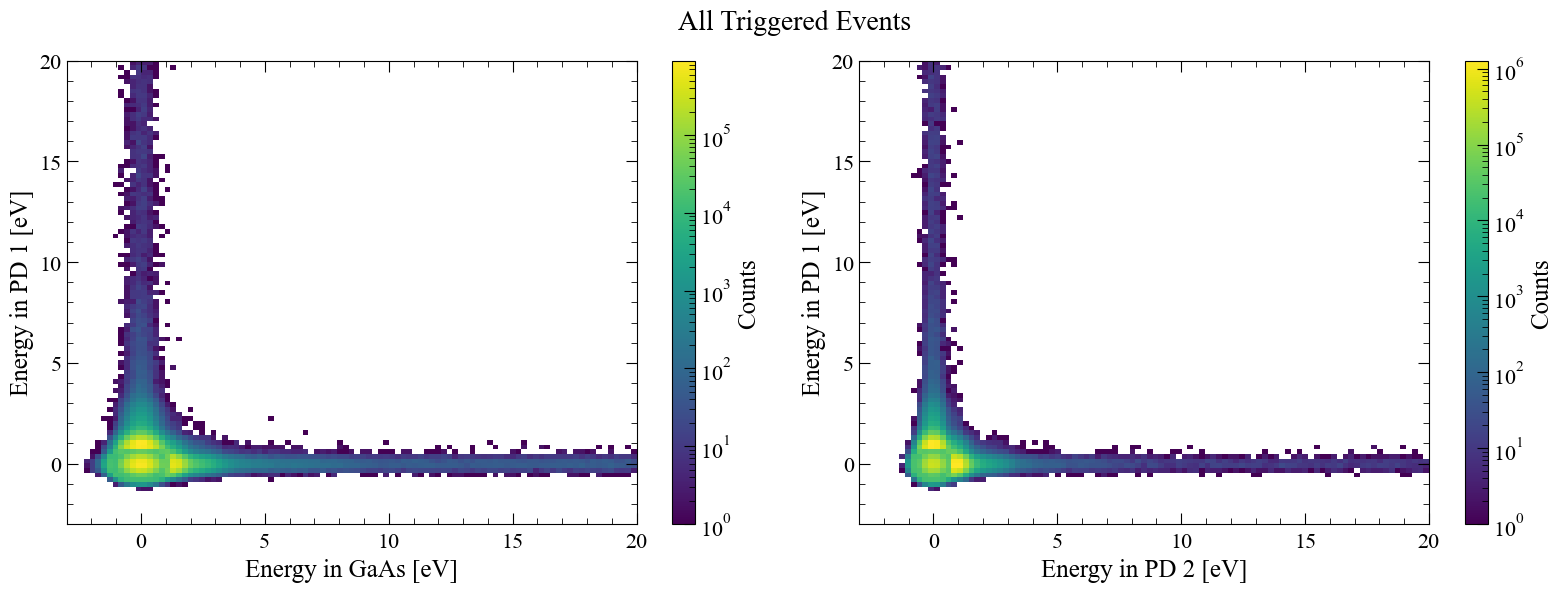

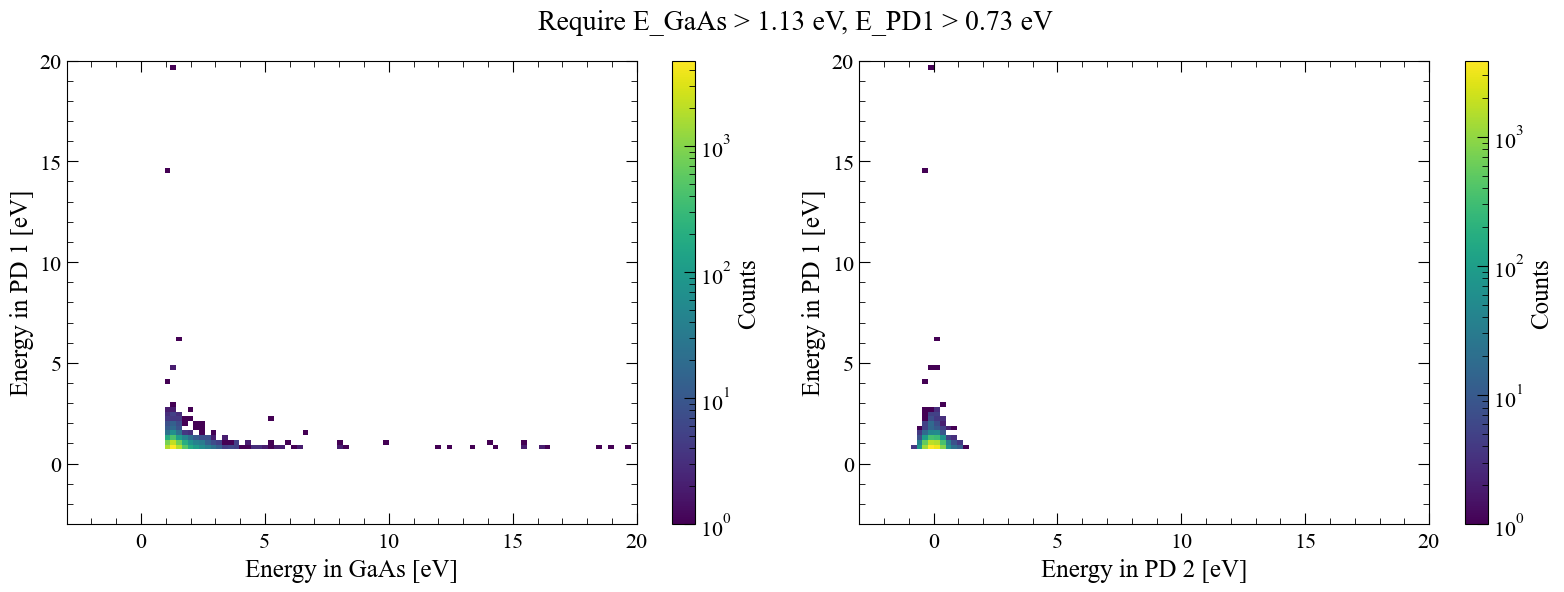

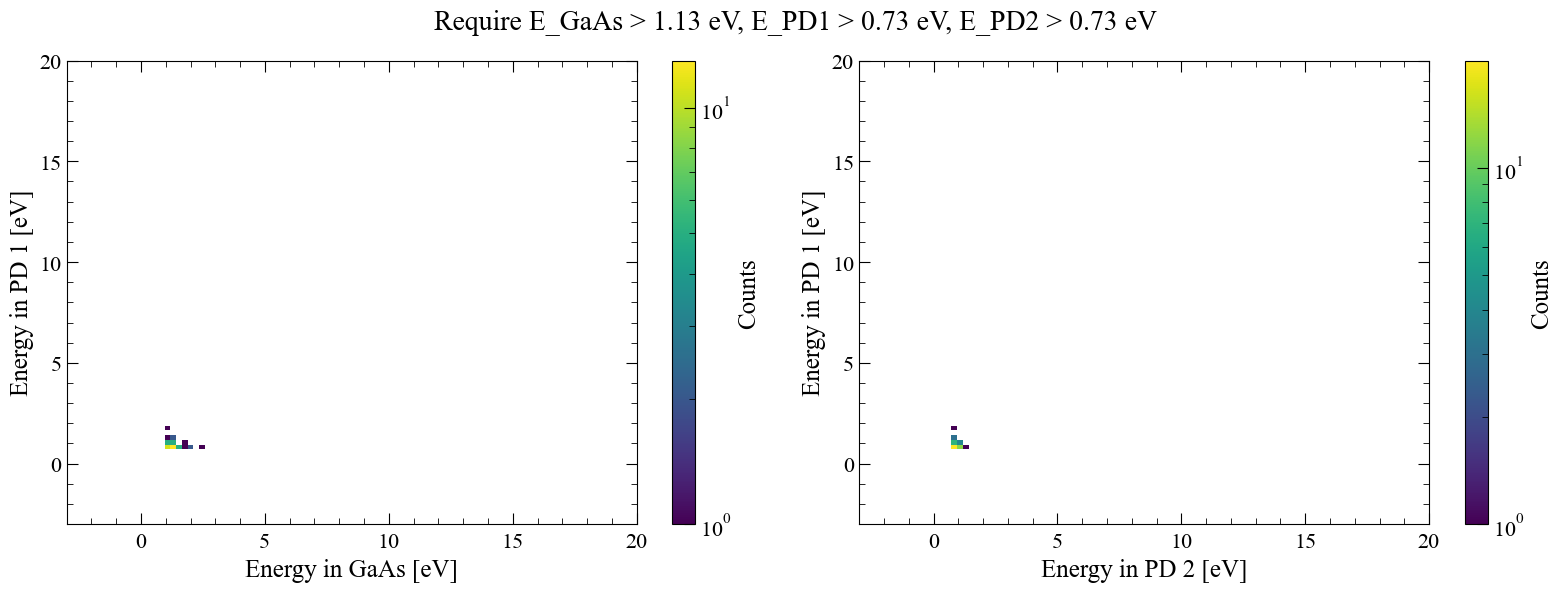

In [8]:
bins = (np.linspace(-3, 20, 100), np.linspace(-3, 20, 100))

########################################################

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

h = ax[0].hist2d(E0_full, E1_full,
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[0], label='Counts')

ax[0].set_xlabel('Energy in GaAs [eV]')
ax[0].set_ylabel('Energy in PD 1 [eV]')
ax[0].set_xlim([-3, 20])
ax[0].set_ylim([-3, 20])

h = ax[1].hist2d(E2_full, E1_full,
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[1], label='Counts')

ax[1].set_xlabel('Energy in PD 2 [eV]')
ax[1].set_ylabel('Energy in PD 1 [eV]')
ax[1].set_xlim([-3, 20])
ax[1].set_ylim([-3, 20])

print(f'{len(E0_full)} triggers, 1-fold coincidence')

fig.suptitle('All Triggered Events', fontsize=20)
fig.tight_layout()
fig.show()

########################################################

cut_2fold = (E0_full > (n_sigma * GaAs_energy_resolution)) * (E1_full > (n_sigma * PD_energy_resolution))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

h = ax[0].hist2d(E0_full[cut_2fold], E1_full[cut_2fold],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[0], label='Counts')

ax[0].set_xlabel('Energy in GaAs [eV]')
ax[0].set_ylabel('Energy in PD 1 [eV]')
ax[0].set_xlim([-3, 20])
ax[0].set_ylim([-3, 20])

h = ax[1].hist2d(E2_full[cut_2fold], E1_full[cut_2fold],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[1], label='Counts')

ax[1].set_xlabel('Energy in PD 2 [eV]')
ax[1].set_ylabel('Energy in PD 1 [eV]')
ax[1].set_xlim([-3, 20])
ax[1].set_ylim([-3, 20])

print(f'{sum(cut_2fold)} triggers, 2-fold coincidence')

fig.suptitle(f'Require E_GaAs > {n_sigma * GaAs_energy_resolution:.2f} eV, E_PD1 > {n_sigma * PD_energy_resolution:.2f} eV', fontsize=20)
fig.tight_layout()
fig.show()

########################################################

cut_3fold = (E0_full > (n_sigma * GaAs_energy_resolution)) * (E1_full > (n_sigma * PD_energy_resolution)) * (E2_full > (n_sigma * PD_energy_resolution))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

h = ax[0].hist2d(E0_full[cut_3fold], E1_full[cut_3fold],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[0], label='Counts')

ax[0].set_xlabel('Energy in GaAs [eV]')
ax[0].set_ylabel('Energy in PD 1 [eV]')
ax[0].set_xlim([-3, 20])
ax[0].set_ylim([-3, 20])

h = ax[1].hist2d(E2_full[cut_3fold], E1_full[cut_3fold],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[1], label='Counts')

ax[1].set_xlabel('Energy in PD 2 [eV]')
ax[1].set_ylabel('Energy in PD 1 [eV]')
ax[1].set_xlim([-3, 20])
ax[1].set_ylim([-3, 20])

print(f'{sum(cut_3fold)} triggers, 3-fold coincidence')
print(f'{sum(cut_3fold * (delta_delta_full < 9))} triggers, 3-fold coincidence with delta delta < 9')

fig.suptitle(f'Require E_GaAs > {n_sigma * GaAs_energy_resolution:.2f} eV, E_PD1 > {n_sigma * PD_energy_resolution:.2f} eV, E_PD2 > {n_sigma * PD_energy_resolution:.2f} eV', fontsize=20)
fig.tight_layout()
fig.show()

# ########################################################

# fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# detected = (E0_full > 2.0) * (E1_full > 0.912) * (E2_full > 0.912)
# print(len(detected), sum(detected))
# detected = detected * (delta_delta_full < 9)
# print(len(detected), sum(detected))

# ax.hist(E0_full, np.linspace(0., 10, 100), density=False, alpha=0.5, label='Pixel 0')
# ax.hist(E1_full, np.linspace(0., 10, 100), density=False, alpha=0.5, label='Pixel 1')
# ax.set_xlabel('Energy in Pixel [eV]')
# ax.set_ylabel('Density (1/eV)')
# #lambda_E_test = 1 / 5.
# #ax.plot(np.linspace(0., 40, 100), lambda_E_test * np.exp(-lambda_E_test * np.linspace(0., 40, 100)), color='k', label=f'Single-Pixel Exponential PDF (tau_E = {1/lambda_E_test} eV)', lw=2)
# ax.legend(loc='best', fontsize=14)

# fig.tight_layout()
# fig.show()

# fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# ax.hist(delta_delta_full[detected], np.linspace(0, 100, 100), density=True)
# ax.set_xlabel('Delta Delta Chi2')
# ax.set_ylabel('Density (1/Delta Delta Chi2)')
# ax.set_xlim([0, 100])
# fig.tight_layout()
# fig.show()

Found 33473464 triggers in PD 1, 33461828 triggers in PD 2, 13920640 triggers in GaAs
Expected duration of simulation: 62.50 days
Expected duration (check): 120.98 days
222327.71200000006 535491.0560000007 535304.2239999996 1069.0720000000053 3.567999999999998
84336397 223 126


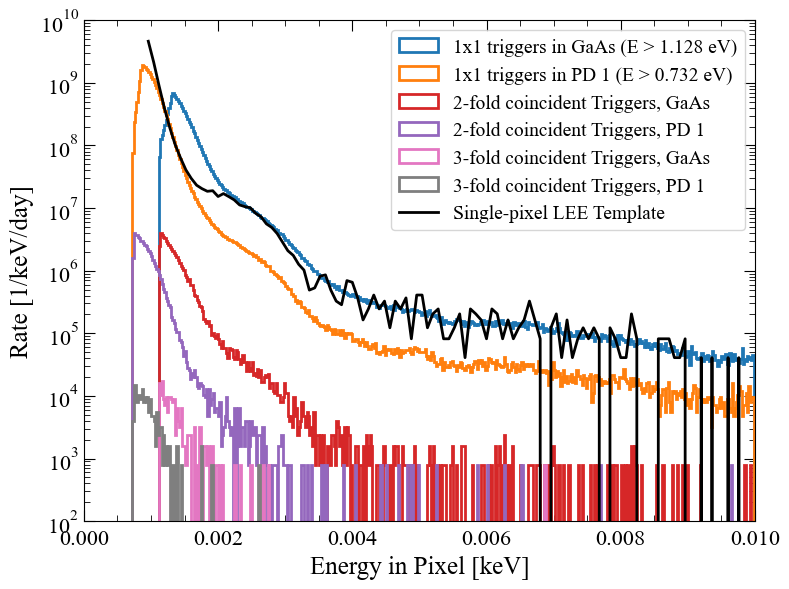

In [5]:
E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

n_triggers_PD_1 = sum(E1_full > E_th_PD)
n_triggers_PD_2 = sum(E2_full > E_th_PD)
n_triggers_GaAs = sum(E0_full > E_th_GaAs)
print(f'Found {n_triggers_PD_1} triggers in PD 1, {n_triggers_PD_2} triggers in PD 2, {n_triggers_GaAs} triggers in GaAs')

duration_s = n_triggers_PD_1 / R_LEE
duration_s = 30 * 3600 * 50
duration_days = duration_s / 86400

print(f'Expected duration of simulation: {duration_days:.2f} days')

E_cutoff_GaAs = (n_sigma * GaAs_energy_resolution) * 1e-3
E_arr_temp = np.geomspace(E_cutoff_GaAs, 20, 250)
dRdE_arr_temp = run57_lee_bkgd()(E_arr_temp)
R_LEE_check = np.trapz(dRdE_arr_temp, E_arr_temp)
print(f'Expected duration (check): {sum(E0_full > E_cutoff_GaAs*1e3) / R_LEE_check / 86400:.2f} days')



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
keV_bins = np.arange(0.1, 10, 0.02) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))

single_pixel = E1_full > E_th_PD
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))

single_pixel = E2_full > E_th_PD
# ax.hist(E2_full[single_pixel]*1e-3, bins=keV_bins,
#         weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
#         histtype='step', color='C2', lw=2,
#         label=f'1x1 triggers in PD 2 (E > {E_th_PD} eV)')
hist_E_E2_single, bin_edges = np.histogram(E2_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_B = sum(hist_E_E2_single * np.diff(bin_edges))

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD 1')
# ax.hist(E2_full[detected]*1e-3, bins=keV_bins,
#         weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
#         histtype='step', color='C5', lw=2,
#         label='Coincident Triggers, PD 2')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))

hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

####################
# 3-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')
# ax.hist(E2_full[detected]*1e-3, bins=keV_bins,
#         weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
#         histtype='step', color='C8', lw=2,
#         label='Coincident Triggers, PD 2')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))

hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

# Export this to a file, but we'll need to renormalize later
E_save = 0.5 * (bin_edges[1:] + bin_edges[:-1])
dRdE_save_GaAs = np.copy(hist_E_2fold_GaAs)
dRdE_save_PD = np.copy(hist_E_3fold_PD)

# detected = (E0_full > 2.) * (E1_full > 0.912) * (delta_delta_full < 9)
# ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
#         weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
#         histtype='step', color='C2', lw=2, ls='--',
#         label='Coincident Triggers, GaAs')
# ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
#         weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
#         histtype='step', color='C3', lw=2, ls='--',
#         label='Coincident Triggers, PD')

# hist_E, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
#                                  weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
# R_coincident_delta = sum(hist_E * np.diff(bin_edges))

E_arr, dRdE_arr, _ = np.loadtxt('Run57_LEE_templates/combined_spectra_shared57.txt', unpack=True)
cut = (E_arr > 0.9e-3) * (E_arr < 10e-3)
E_arr = E_arr[cut]
dRdE_arr = dRdE_arr[cut]
ax.plot(E_arr, dRdE_arr, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
#ax.set_ylim([1e4, 4e9])

# ax.text(0.005, 5e7, f'R = {R_all:.3e} per day', ha='left', va='top', fontsize=16, color='C0')
# ax.text(0.005, 2e7, f'R = {R_2fold:.3e} per day', ha='left', va='top', fontsize=16, color='C1')
# ax.text(0.005, 8e6, f'R = {R_2fold_dchi2:.3e} per day', ha='left', va='top', fontsize=16, color='C2')

ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.legend(loc='best', fontsize=14)
ax.set_ylim([1e2, 1e10])
ax.set_xlim([0, 10e-3])

fig.tight_layout()
fig.show()

print(R_single_GaAs, R_single_PD_A, R_single_PD_B, R_coincident_2fold, R_coincident_3fold)

print(len(detected), sum(detected), sum(detected * (delta_delta_full < 9)))

# Save the histogram data to a file
dRdE_save_GaAs *= (R_coincident_3fold / R_coincident_2fold)
np.savetxt('required_performance_updated_0p55eV_cutoff_5sigma/background_spectrum.txt',
           np.column_stack((E_save, dRdE_save_GaAs, dRdE_save_PD)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]     dRdE PD [1/keV/day]',
           fmt='%.4e')